# 9주차 실습 (2) — Stochastic Processes

> **구조를 가진 무작위성. 랜덤 워크, 마르코프 연쇄, 그리고 디퓨전 모델의 수학입니다.**

- **Type:** Learn · **Language:** Python · **Time:** ~75분
- **선수 지식:** Phase 1 Lesson 06~07 (확률, 베이즈) · **6주차 샘플링**
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/22-stochastic-processes>

## 🎯 학습 목표

1. **1D·2D 랜덤 워크**를 시뮬레이션하고 변위가 **√n으로 커지는 것**을 확인합니다.
2. **마르코프 연쇄**를 만들고 **정상 분포**를 고유분해로 구합니다.
3. **랑주뱅 동역학**으로 목표 분포에서 샘플링합니다.
4. **순방향 확산이 브라운 운동**임을 연결하고, 역방향이 어떻게 데이터를 생성하는지 설명합니다.

---

## 📖 이 노트북을 읽는 법

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 시간에 따라 진화하는 무작위성 |
| 1 | 랜덤 워크와 √n 법칙 |
| 2 | 2D 랜덤 워크 · 도박꾼의 파산 |
| 3 | 브라운 운동 — 랜덤 워크의 연속 극한 |
| 4 | 🔑 마르코프 연쇄와 전이 행렬 |
| 5 | 정상 분포 — 두 가지 구하는 법 |
| 6 | 수렴 조건과 혼합 시간 (스펙트럴 갭) |
| 7 | 흡수 상태 |
| 8 | 🔨 랑주뱅 동역학 — 노이즈를 더한 경사하강 |
| 9 | 🏭 디퓨전 모델 — 순방향과 역방향 |
| 10 | 🏭 언어모델의 토큰 생성도 마르코프 과정입니다 |
| 11 | 📝 연습문제 5개 (풀이 포함) |
| 12 | 📚 용어 사전 · 더 읽을거리 |

> 💡 **6주차 샘플링 노트북과 겹치는 부분**(Metropolis-Hastings, MCMC 기초)은
> 여기서 반복하지 않고 **연결점만 짚습니다.** 대신 랜덤 워크·마르코프 연쇄·랑주뱅·디퓨전에 집중합니다.

## 0️⃣ 문제 상황 — 시간에 따라 진화하는 무작위성

많은 AI 시스템이 무작위성을 다룹니다. 그런데 **정적인** 무작위성이 아니라,
**각 단계가 그 전 단계에 의존하는 순차적이고 구조화된 무작위성**입니다.

**언어모델**은 토큰을 하나씩 생성합니다. 각 토큰이 앞의 문맥에 의존하죠.
확률분포를 출력하고, 거기서 샘플링하고, 다음으로 넘어갑니다. **그게 확률 과정입니다.**

**디퓨전 모델**은 이미지에 노이즈를 한 단계씩 더해 완전한 잡음으로 만듭니다.
그리고 그 과정을 되돌려 한 단계씩 노이즈를 제거해 새 이미지를 만들죠.
**순방향은 마르코프 연쇄**이고, **역방향은 학습된 마르코프 연쇄를 거꾸로 돌리는 것**입니다.

**강화학습** 에이전트는 환경에서 행동합니다. 각 행동이 확률적으로 새 상태로 이어지죠.
**전체가 마르코프 결정 과정**입니다.

**MCMC** — 베이즈 추론의 척추 — 는 사후분포를 정상 분포로 갖는 마르코프 연쇄를 구성합니다.

### 🧭 네 가지 기초 아이디어

```
1. 랜덤 워크        (1~3절)  ← 가장 단순한 확률 과정
2. 마르코프 연쇄     (4~7절)  ← 전이 행렬로 구조화된 무작위성
3. 랑주뱅 동역학     (8절)    ← 노이즈를 더한 경사하강
4. Metropolis-Hastings      ← 6주차에서 이미 다뤘습니다
```

그리고 전부 **9절의 디퓨전 모델**에서 만납니다.

```
    랜덤 워크 ──(연속 극한)──> 브라운 운동
        │                          │
        │                          ▼
        └──(구조 추가)──> 마르코프 연쇄 ──> 디퓨전 순방향
                              │                  │
                              ▼                  ▼
                          정상 분포          디퓨전 역방향
                       (MCMC·PageRank)      (= 생성 모델)
```

> 🔗 **바로 앞 노트북(그래프)의 PageRank가 여기서 다시 나옵니다.**
> PageRank는 그래프 위 랜덤 워크의 **정상 분포**였죠. 5절에서 그 정체를 확인합니다.

In [1]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=5, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두면 축 눈금의 유니코드 마이너스(U+2212)가 깨지지 않습니다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


## 1️⃣ 랜덤 워크와 √n 법칙

위치 0에서 시작합니다. 매 걸음마다 공정한 동전을 던져서,
앞면이면 오른쪽(+1), 뒷면이면 왼쪽(−1)으로 갑니다.

`n`걸음 뒤의 위치는 `n`개의 ±1을 더한 값입니다.
**기대 위치는 0**입니다(편향이 없으니까요).
**그런데 원점에서 떨어진 거리의 기대값은 `√n`으로 커집니다.**

### 🔑 이게 직관에 반합니다

걸음은 공정합니다. 어느 쪽으로도 치우치지 않아요.
**그런데도 시간이 지날수록 출발점에서 점점 더 멀어집니다.**

### 📐 왜 √n 인가

각 걸음 `Xᵢ`는 ±1이고, 분산은 1입니다. 걸음들이 **독립**이므로:

$$\text{Var}(S_n) = \text{Var}(X_1 + \cdots + X_n) = n \quad\Longrightarrow\quad \text{표준편차} = \sqrt{n}$$

**독립인 확률변수를 더하면 분산이 더해집니다.** 표준편차는 그 제곱근이고요.
그리고 중심극한정리에 의해 `Sₙ/√n`은 표준정규분포로 수렴합니다.

```
100걸음 뒤   : 원점에서 대략 10  (√100)
10,000걸음 뒤 : 원점에서 대략 100 (√10000)
```

> 🔑 **이 √n 스케일링은 ML 어디에나 있습니다.**
> - SGD 노이즈가 `1/√(배치 크기)`로 줄어듭니다
> - 임베딩 차원이 `√d`로 스케일됩니다 (어텐션의 `1/√d_k`)
> - 6주차 몬테카를로 오차가 `O(1/√N)`이었죠
>
> **제곱근은 "독립적인 무작위 덧셈"의 서명입니다.**

In [2]:
def random_walk_1d(n_steps, seed=None):
    rng = np.random.default_rng(seed)
    steps = rng.choice([-1, 1], size=n_steps)
    return np.concatenate([[0], np.cumsum(steps)])

# 연습 1 — 여러 개의 워크를 돌려 √n 법칙을 확인합니다
N_WALKS, N_STEPS = 2000, 10000
rng = np.random.default_rng(42)
all_steps = rng.choice([-1, 1], size=(N_WALKS, N_STEPS))
paths = np.cumsum(all_steps, axis=1)

print(f"랜덤 워크 {N_WALKS:,}개 × {N_STEPS:,}걸음\n")
print(f"{'걸음 수 n':>12}{'평균 위치':>14}{'표준편차':>14}{'√n':>12}{'비율':>10}")
print("-" * 64)
for n in [10, 100, 1000, 5000, 10000]:
    pos = paths[:, n-1]
    print(f"{n:>12,}{pos.mean():>14.3f}{pos.std():>14.3f}{math.sqrt(n):>12.3f}"
          f"{pos.std()/math.sqrt(n):>10.4f}")

print("\n=> 평균 위치는 0 근처를 맴돕니다 (편향이 없으니까요).")
print("   그런데 표준편차는 정확히 √n 을 따라갑니다. 마지막 열이 1에 붙어 있죠.")
print("   '공정한데도 점점 멀어진다' — 이게 랜덤 워크의 핵심입니다.")

final = paths[:, -1]
print(f"\n[중심극한정리 확인] {N_STEPS:,}걸음 뒤 최종 위치의 분포")
print(f"  평균 {final.mean():>8.3f}  (이론값 0)")
print(f"  표준편차 {final.std():>8.3f}  (이론값 √{N_STEPS} = {math.sqrt(N_STEPS):.1f})")
from scipy import stats as sps
print(f"  왜도 {sps.skew(final):>8.4f}   초과첨도 {sps.kurtosis(final):>8.4f}  (정규분포면 둘 다 0)")
within = np.mean(np.abs(final) < math.sqrt(N_STEPS))
print(f"  ±1σ 안에 든 비율 {within:.1%}  (정규분포 이론값 68.3%)")

랜덤 워크 2,000개 × 10,000걸음

      걸음 수 n         평균 위치          표준편차          √n        비율
----------------------------------------------------------------
          10         0.020         3.259       3.162    1.0305
         100         0.307         9.938      10.000    0.9938
       1,000         0.558        31.689      31.623    1.0021
       5,000        -0.459        70.096      70.711    0.9913
      10,000        -2.175        96.954     100.000    0.9695

=> 평균 위치는 0 근처를 맴돕니다 (편향이 없으니까요).
   그런데 표준편차는 정확히 √n 을 따라갑니다. 마지막 열이 1에 붙어 있죠.
   '공정한데도 점점 멀어진다' — 이게 랜덤 워크의 핵심입니다.

[중심극한정리 확인] 10,000걸음 뒤 최종 위치의 분포
  평균   -2.175  (이론값 0)
  표준편차   96.954  (이론값 √10000 = 100.0)
  왜도   0.0543   초과첨도  -0.1505  (정규분포면 둘 다 0)
  ±1σ 안에 든 비율 68.5%  (정규분포 이론값 68.3%)


### 🖼️ 그림 1 — √n 법칙

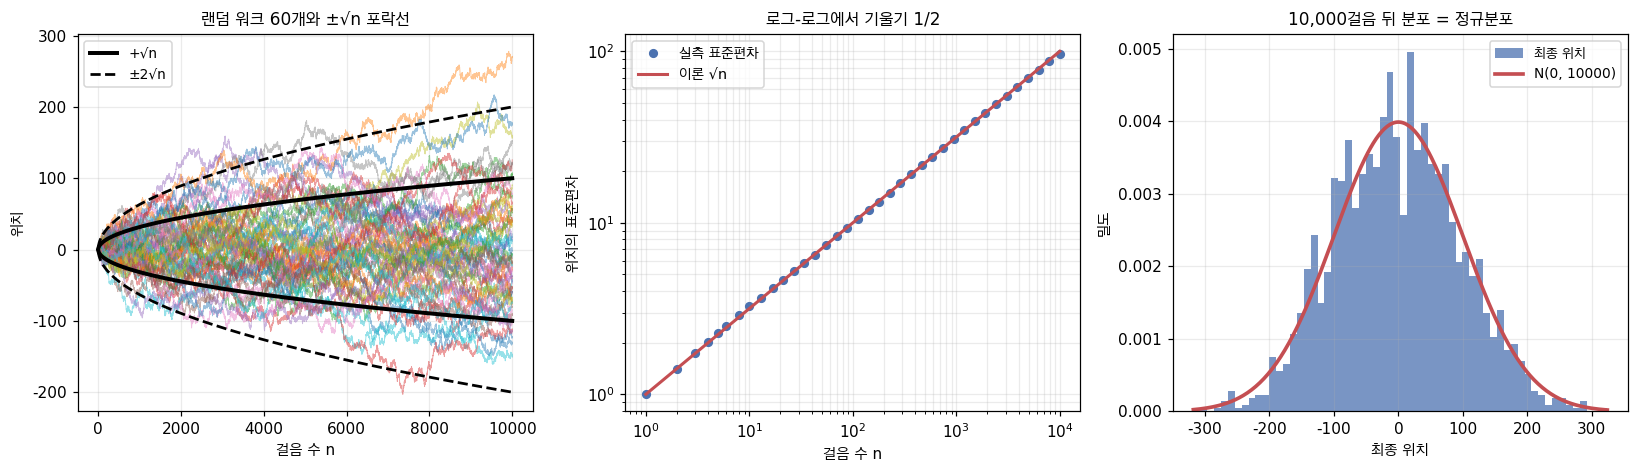

로그-로그 기울기 측정값: 0.4975  (이론값 0.5)

왼쪽 그림에서 대부분의 경로가 ±2√n 포락선 안에 머뭅니다.
오른쪽은 6주차에서 배운 중심극한정리의 또 다른 얼굴입니다 —
독립인 ±1을 만 번 더하면 정규분포가 나옵니다.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (1) 여러 경로
ns = np.arange(1, N_STEPS + 1)
for i in range(60):
    axes[0].plot(ns, paths[i], lw=0.6, alpha=0.45)
axes[0].plot(ns, np.sqrt(ns), lw=2.6, color="black", label="+√n")
axes[0].plot(ns, -np.sqrt(ns), lw=2.6, color="black")
axes[0].plot(ns, 2*np.sqrt(ns), lw=1.8, color="black", ls="--", label="±2√n")
axes[0].plot(ns, -2*np.sqrt(ns), lw=1.8, color="black", ls="--")
axes[0].set_xlabel("걸음 수 n"); axes[0].set_ylabel("위치")
axes[0].set_title("랜덤 워크 60개와 ±√n 포락선", fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.25)

# (2) 표준편차 vs √n
check_ns = np.unique(np.logspace(0, np.log10(N_STEPS), 40).astype(int))
sds = [paths[:, n-1].std() for n in check_ns]
axes[1].loglog(check_ns, sds, "o", ms=5, color="#4c72b0", label="실측 표준편차")
axes[1].loglog(check_ns, np.sqrt(check_ns), lw=2, color="#c44e52", label="이론 √n")
axes[1].set_xlabel("걸음 수 n"); axes[1].set_ylabel("위치의 표준편차")
axes[1].set_title("로그-로그에서 기울기 1/2", fontsize=11)
axes[1].legend(fontsize=9.5); axes[1].grid(alpha=0.25, which="both")

# (3) 최종 위치 분포 vs 정규분포
axes[2].hist(final, bins=60, density=True, color="#4c72b0", alpha=0.75, label="최종 위치")
xs = np.linspace(final.min(), final.max(), 300)
axes[2].plot(xs, sps.norm.pdf(xs, 0, math.sqrt(N_STEPS)), lw=2.4, color="#c44e52",
             label=f"N(0, {N_STEPS})")
axes[2].set_xlabel("최종 위치"); axes[2].set_ylabel("밀도")
axes[2].set_title(f"{N_STEPS:,}걸음 뒤 분포 = 정규분포", fontsize=11)
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

slope = np.polyfit(np.log(check_ns), np.log(sds), 1)[0]
print(f"로그-로그 기울기 측정값: {slope:.4f}  (이론값 0.5)")
print("\n왼쪽 그림에서 대부분의 경로가 ±2√n 포락선 안에 머뭅니다.")
print("오른쪽은 6주차에서 배운 중심극한정리의 또 다른 얼굴입니다 —")
print("독립인 ±1을 만 번 더하면 정규분포가 나옵니다.")

## 2️⃣ 2D 랜덤 워크 · 도박꾼의 파산

### 📐 2D에서도 √n

2차원에서는 상하좌우 네 방향으로 같은 확률로 움직입니다.
**원점으로부터의 거리에 대해서도 같은 √n 스케일링이 적용됩니다.**
경로는 프랙탈 같은 무늬를 그립니다.

### 📐 도박꾼의 파산 (Gambler's Ruin)

위치 `k`에서 시작하는 랜덤 워커가 있고, 0과 `N`에 **흡수벽**이 있습니다.
0에 닿으면 파산, `N`에 닿으면 목표 달성입니다.

> **공정한 게임에서 `N`에 먼저 도달할 확률은 정확히 `k/N`입니다.**

놀랍도록 단순하죠. 그리고 이게 **마팅게일** 이론과 연결됩니다.
공정한 랜덤 워크는 마팅게일입니다 — **미래의 기대값 = 현재 값**.

시작점 `k`에서 기대값이 `k`인데, 끝날 때는 0 아니면 `N`이므로:

$$k = 0 \cdot P(\text{파산}) + N \cdot P(\text{달성}) \quad\Longrightarrow\quad P(\text{달성}) = \frac{k}{N}$$

**멋진 건 이 논증에 미적분이 전혀 필요 없다는 점입니다.**

> ⚠️ 그런데 게임이 **조금이라도 불리하면** 이야기가 완전히 달라집니다.
> 아래에서 확률 0.49짜리 게임이 얼마나 잔인한지 확인해 보겠습니다.

In [4]:
def random_walk_2d(n_steps, seed=None):
    rng = np.random.default_rng(seed)
    d = rng.integers(0, 4, size=n_steps)
    dx = np.where(d == 0, 1, np.where(d == 1, -1, 0))
    dy = np.where(d == 2, 1, np.where(d == 3, -1, 0))
    return np.concatenate([[0], np.cumsum(dx)]), np.concatenate([[0], np.cumsum(dy)])

print("[2D 랜덤 워크도 √n을 따릅니다]")
rng = np.random.default_rng(7)
n2 = 5000
trials = 2000
d2 = rng.integers(0, 4, size=(trials, n2))
dx = np.where(d2 == 0, 1, np.where(d2 == 1, -1, 0)).cumsum(axis=1)
dy = np.where(d2 == 2, 1, np.where(d2 == 3, -1, 0)).cumsum(axis=1)
print(f"{'걸음 n':>10}{'평균 거리':>14}{'√n':>12}{'비율':>10}")
print("-" * 48)
for n in [100, 500, 2000, 5000]:
    dist = np.sqrt(dx[:, n-1]**2 + dy[:, n-1]**2)
    print(f"{n:>10,}{dist.mean():>14.3f}{math.sqrt(n):>12.3f}{dist.mean()/math.sqrt(n):>10.4f}")
print("\n  (비율이 1이 아니라 약 0.886인 이유: 2D에서 각 축의 분산이 절반씩이고,")
print("   레일리 분포의 평균이 σ√(π/2)라 상수 배가 붙습니다. 스케일링은 여전히 √n입니다)")

def gamblers_ruin(k, N, p=0.5, trials=20000, seed=0):
    rng = np.random.default_rng(seed)
    wins = 0
    for _ in range(trials):
        pos = k
        while 0 < pos < N:
            pos += 1 if rng.random() < p else -1
        wins += (pos == N)
    return wins / trials

print("\n[도박꾼의 파산 — 공정한 게임 (p = 0.5)]")
N_goal = 20
print(f"목표 {N_goal}, 파산선 0\n")
print(f"{'시작 자금 k':>14}{'실측 성공률':>16}{'이론값 k/N':>14}")
print("-" * 46)
for k in [1, 5, 10, 15, 19]:
    emp = gamblers_ruin(k, N_goal, 0.5, trials=8000, seed=k)
    print(f"{k:>14}{emp:>15.3f}{k/N_goal:>14.3f}")
print("\n=> 실측이 k/N 에 정확히 맞습니다. 마팅게일 논증이 예측한 그대로입니다.")

print("\n[⚠️ 게임이 조금만 불리해지면]")
print(f"{'승률 p':>10}{'k=10에서 20까지 갈 확률':>26}{'공정 대비':>12}")
print("-" * 50)
for p in [0.50, 0.49, 0.48, 0.45]:
    emp = gamblers_ruin(10, 20, p, trials=8000, seed=1)
    print(f"{p:>10.2f}{emp:>25.3f}{emp/0.5:>12.2f}배")
print("\n=> 승률이 1%p만 떨어져도(0.50→0.49) 성공 확률이 눈에 띄게 줄어듭니다.")
print("   카지노의 하우스 엣지가 왜 그렇게 작아도 되는지 보여 주는 계산입니다.")

[2D 랜덤 워크도 √n을 따릅니다]
      걸음 n         평균 거리          √n        비율
------------------------------------------------
       100         8.880      10.000    0.8880
       500        19.860      22.361    0.8882
     2,000        39.454      44.721    0.8822
     5,000        63.363      70.711    0.8961

  (비율이 1이 아니라 약 0.886인 이유: 2D에서 각 축의 분산이 절반씩이고,
   레일리 분포의 평균이 σ√(π/2)라 상수 배가 붙습니다. 스케일링은 여전히 √n입니다)

[도박꾼의 파산 — 공정한 게임 (p = 0.5)]
목표 20, 파산선 0

       시작 자금 k          실측 성공률       이론값 k/N
----------------------------------------------
             1          0.050         0.050
             5          0.250         0.250
            10          0.497         0.500
            15          0.750         0.750
            19          0.947         0.950

=> 실측이 k/N 에 정확히 맞습니다. 마팅게일 논증이 예측한 그대로입니다.

[⚠️ 게임이 조금만 불리해지면]
      승률 p          k=10에서 20까지 갈 확률       공정 대비
--------------------------------------------------
      0.50                    0.505        1.01배
      0.49             

### 🖼️ 그림 2 — 2D 경로와 도박꾼의 파산

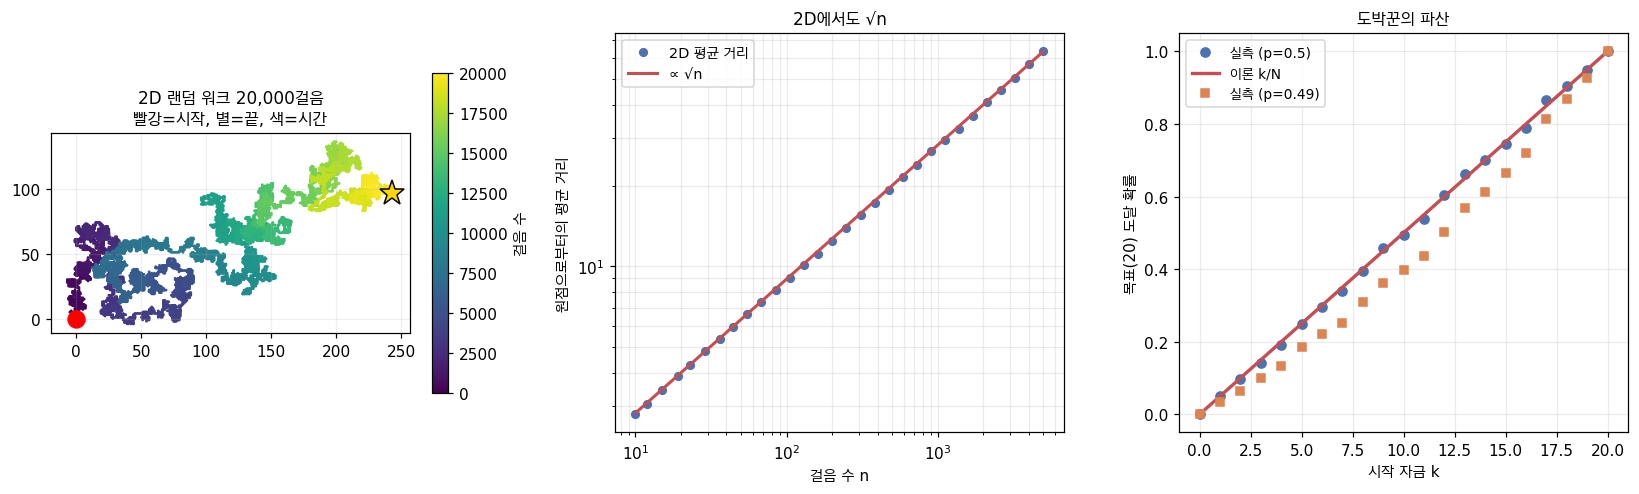

가운데 그림: 2D에서도 기울기가 1/2입니다. 차원이 늘어도 √n은 변하지 않습니다.
오른쪽: 파란 점(공정)은 정확히 직선 위에 있고,
주황 점(p=0.49)은 그 아래로 휘어 있습니다 — 특히 자금이 적을 때 더 불리합니다.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# (1) 2D 경로 하나
x2, y2 = random_walk_2d(20000, seed=3)
pts = axes[0].scatter(x2, y2, c=np.arange(len(x2)), cmap="viridis", s=0.6)
axes[0].plot(0, 0, "o", ms=11, color="red", zorder=5)
axes[0].plot(x2[-1], y2[-1], "*", ms=17, color="gold", markeredgecolor="black", zorder=5)
axes[0].set_aspect("equal")
axes[0].set_title("2D 랜덤 워크 20,000걸음\n빨강=시작, 별=끝, 색=시간", fontsize=11)
axes[0].grid(alpha=0.2)
plt.colorbar(pts, ax=axes[0], shrink=0.8, label="걸음 수")

# (2) 2D 거리 vs √n
check = np.unique(np.logspace(1, np.log10(n2), 30).astype(int))
mean_d = [np.sqrt(dx[:, n-1]**2 + dy[:, n-1]**2).mean() for n in check]
axes[1].loglog(check, mean_d, "o", ms=5, color="#4c72b0", label="2D 평균 거리")
axes[1].loglog(check, np.sqrt(check) * mean_d[-1]/math.sqrt(check[-1]), lw=2,
               color="#c44e52", label="∝ √n")
axes[1].set_xlabel("걸음 수 n"); axes[1].set_ylabel("원점으로부터의 평균 거리")
axes[1].set_title("2D에서도 √n", fontsize=11)
axes[1].legend(fontsize=9.5); axes[1].grid(alpha=0.25, which="both")

# (3) 도박꾼의 파산
ks = np.arange(0, 21)
emp = [gamblers_ruin(k, 20, 0.5, trials=3000, seed=k) if 0 < k < 20 else float(k == 20)
       for k in ks]
axes[2].plot(ks, emp, "o", ms=6, color="#4c72b0", label="실측 (p=0.5)")
axes[2].plot(ks, ks/20, lw=2.2, color="#c44e52", label="이론 k/N")
emp49 = [gamblers_ruin(k, 20, 0.49, trials=3000, seed=k) if 0 < k < 20 else float(k == 20)
         for k in ks]
axes[2].plot(ks, emp49, "s", ms=5, color="#dd8452", label="실측 (p=0.49)")
axes[2].set_xlabel("시작 자금 k"); axes[2].set_ylabel("목표(20) 도달 확률")
axes[2].set_title("도박꾼의 파산", fontsize=11)
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("가운데 그림: 2D에서도 기울기가 1/2입니다. 차원이 늘어도 √n은 변하지 않습니다.")
print("오른쪽: 파란 점(공정)은 정확히 직선 위에 있고,")
print("주황 점(p=0.49)은 그 아래로 휘어 있습니다 — 특히 자금이 적을 때 더 불리합니다.")

## 3️⃣ 브라운 운동 — 랜덤 워크의 연속 극한

걸음 크기를 `1/√n`으로 줄이고 단위 시간당 `n`걸음을 걷게 해 봅시다.
`n → ∞`로 보내면 **브라운 운동 `B(t)`** 로 수렴합니다.

### 📐 브라운 운동의 세 가지 성질

1. `B(0) = 0`
2. `B(t) − B(s)`는 **평균 0, 분산 `t−s`인 정규분포** (`t > s`)
3. 겹치지 않는 구간의 증분은 **서로 독립**

브라운 운동은 **연속이지만 어디서도 미분 불가능**합니다.
모든 스케일에서 떨고 있어요. 평면에서의 프랙탈 차원은 2입니다.

### 📐 이산 시뮬레이션

$$B(t + dt) = B(t) + \sqrt{dt}\cdot z, \qquad z \sim N(0,1)$$

> 🔑 **`√dt` 스케일링이 핵심입니다.** `dt`가 아니라 `√dt`예요.
> 랜덤 워크의 √n 법칙에서 그대로 나온 것입니다.
> 시간 간격을 100배 잘게 쪼개면 각 걸음은 10배만 작아집니다.

브라운 운동은 유체 속 입자의 무작위 진동, 주가의 요동, 그리고 **디퓨전 모델의 노이즈 과정**을 모형화합니다.

In [6]:
def brownian(T=1.0, n_steps=1000, seed=None):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    incr = np.sqrt(dt) * rng.normal(size=n_steps)
    return np.linspace(0, T, n_steps+1), np.concatenate([[0], np.cumsum(incr)])

print("[성질 2 검증] B(t)의 분산이 정확히 t 인가")
T = 1.0
n_paths = 4000
rng = np.random.default_rng(11)
n_st = 1000
dt = T / n_st
incr = np.sqrt(dt) * rng.normal(size=(n_paths, n_st))
B = np.cumsum(incr, axis=1)
print(f"{'시각 t':>10}{'실측 분산':>14}{'이론 분산 = t':>16}{'실측 평균':>14}")
print("-" * 56)
for t in [0.1, 0.25, 0.5, 0.75, 1.0]:
    i = int(t / dt) - 1
    print(f"{t:>10.2f}{B[:, i].var():>14.5f}{t:>16.2f}{B[:, i].mean():>14.5f}")

print("\n[성질 3 검증] 겹치지 않는 구간의 증분이 독립인가")
seg1 = B[:, int(0.3/dt)-1] - B[:, 0]                      # [0, 0.3]
seg2 = B[:, int(0.9/dt)-1] - B[:, int(0.6/dt)-1]          # [0.6, 0.9]
print(f"  두 증분의 상관계수: {np.corrcoef(seg1, seg2)[0,1]:+.5f}  (독립이면 0)")

print("\n[⚠️ 브라운 운동은 미분 불가능합니다]")
print("  시간 간격을 잘게 쪼갤수록 '기울기'가 발산하는지 확인합니다\n")
print(f"{'dt':>12}{'|ΔB/Δt| 평균':>18}{'1/√dt':>14}")
print("-" * 46)
for n_s in [100, 1000, 10000, 100000]:
    d = T / n_s
    z = np.sqrt(d) * np.random.default_rng(5).normal(size=n_s)
    print(f"{d:>12.2e}{np.abs(z/d).mean():>18.2f}{1/math.sqrt(d):>14.2f}")
print("\n  => 간격을 줄일수록 기울기가 1/√dt 로 발산합니다. 극한에서 미분이 존재하지 않습니다.")
print("     '연속인데 어디서도 미분 불가능'이라는 게 이런 뜻입니다.")

[성질 2 검증] B(t)의 분산이 정확히 t 인가
      시각 t         실측 분산       이론 분산 = t         실측 평균
--------------------------------------------------------
      0.10       0.09823            0.10       0.01027
      0.25       0.24666            0.25       0.00198
      0.50       0.50729            0.50       0.00679
      0.75       0.75098            0.75       0.01652
      1.00       0.99647            1.00       0.02388

[성질 3 검증] 겹치지 않는 구간의 증분이 독립인가
  두 증분의 상관계수: -0.01022  (독립이면 0)

[⚠️ 브라운 운동은 미분 불가능합니다]
  시간 간격을 잘게 쪼갤수록 '기울기'가 발산하는지 확인합니다

          dt        |ΔB/Δt| 평균         1/√dt
----------------------------------------------
    1.00e-02              7.41         10.00
    1.00e-03             25.18         31.62
    1.00e-04             80.39        100.00
    1.00e-05            251.86        316.23

  => 간격을 줄일수록 기울기가 1/√dt 로 발산합니다. 극한에서 미분이 존재하지 않습니다.
     '연속인데 어디서도 미분 불가능'이라는 게 이런 뜻입니다.


### 🖼️ 그림 3 — 랜덤 워크가 브라운 운동으로

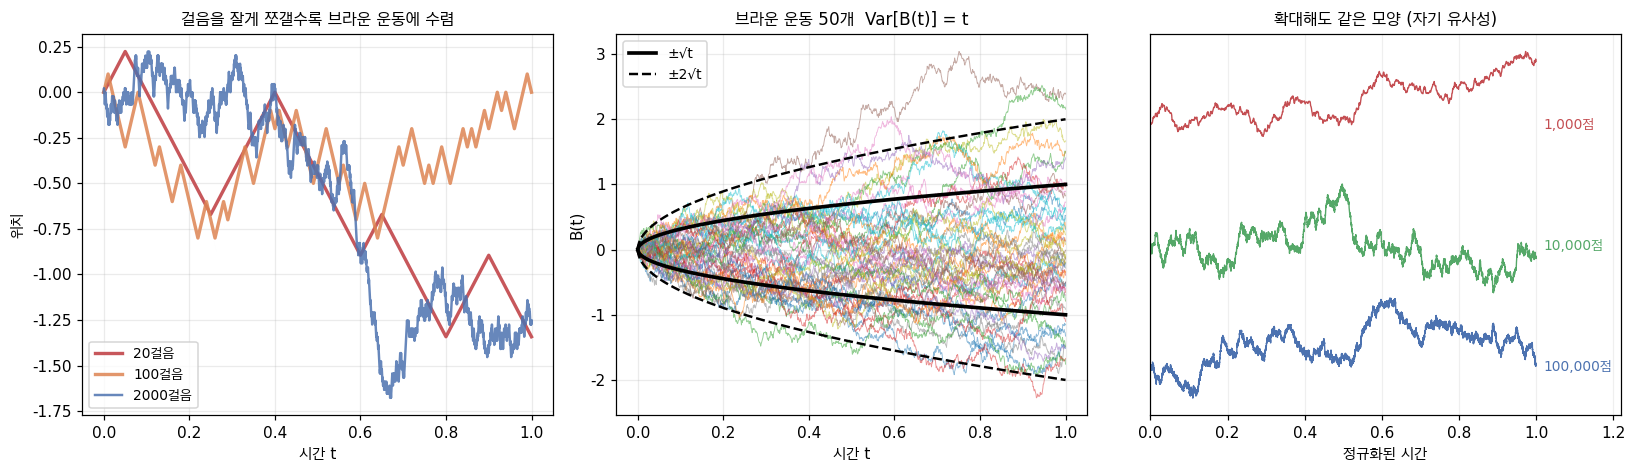

오른쪽 그림이 '어디서도 미분 불가능'의 시각적 의미입니다.
10만 점을 1만 점으로, 다시 1천 점으로 확대해도 매끄러워지지 않습니다.
보통 함수라면 충분히 확대했을 때 직선처럼 보여야 하는데(그게 미분 가능성입니다),
브라운 운동은 아무리 확대해도 똑같이 삐죽삐죽합니다.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# (1) 걸음 수를 늘리면 랜덤 워크가 브라운 운동에 수렴
for n_s, color, alpha in [(20, "#c44e52", 0.95), (100, "#dd8452", 0.85),
                          (2000, "#4c72b0", 0.85)]:
    r = np.random.default_rng(3)
    st = r.choice([-1, 1], size=n_s) / math.sqrt(n_s)      # 걸음 크기 1/√n
    axes[0].plot(np.linspace(0, 1, n_s+1), np.concatenate([[0], np.cumsum(st)]),
                 lw=1.6 if n_s > 500 else 2.2, color=color, alpha=alpha,
                 label=f"{n_s}걸음")
axes[0].set_xlabel("시간 t"); axes[0].set_ylabel("위치")
axes[0].set_title("걸음을 잘게 쪼갤수록 브라운 운동에 수렴", fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.25)

# (2) 여러 경로와 ±√t 포락선
ts = np.linspace(0, T, n_st)
for i in range(50):
    axes[1].plot(ts, B[i], lw=0.6, alpha=0.5)
axes[1].plot(ts, np.sqrt(ts), lw=2.4, color="black", label="±√t")
axes[1].plot(ts, -np.sqrt(ts), lw=2.4, color="black")
axes[1].plot(ts, 2*np.sqrt(ts), lw=1.6, color="black", ls="--", label="±2√t")
axes[1].plot(ts, -2*np.sqrt(ts), lw=1.6, color="black", ls="--")
axes[1].set_xlabel("시간 t"); axes[1].set_ylabel("B(t)")
axes[1].set_title("브라운 운동 50개  Var[B(t)] = t", fontsize=11)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.25)

# (3) 확대해도 같은 모양 — 자기 유사성
t_full, b_full = brownian(1.0, 100000, seed=8)
for k, (lo, hi, color) in enumerate([(0, 100000, "#4c72b0"),
                                     (40000, 50000, "#55a868"),
                                     (44000, 45000, "#c44e52")]):
    seg = b_full[lo:hi]
    seg = (seg - seg[0]) / (np.std(seg) + 1e-12)
    axes[2].plot(np.linspace(0, 1, len(seg)), seg + k*6, lw=0.9, color=color)
    axes[2].text(1.02, k*6, f"{hi-lo:,}점", fontsize=9, va="center", color=color)
axes[2].set_xlim(0, 1.22)
axes[2].set_yticks([])
axes[2].set_xlabel("정규화된 시간")
axes[2].set_title("확대해도 같은 모양 (자기 유사성)", fontsize=11)
axes[2].grid(alpha=0.2, axis="x")

plt.tight_layout()
plt.show()

print("오른쪽 그림이 '어디서도 미분 불가능'의 시각적 의미입니다.")
print("10만 점을 1만 점으로, 다시 1천 점으로 확대해도 매끄러워지지 않습니다.")
print("보통 함수라면 충분히 확대했을 때 직선처럼 보여야 하는데(그게 미분 가능성입니다),")
print("브라운 운동은 아무리 확대해도 똑같이 삐죽삐죽합니다.")

## 4️⃣ 🔑 마르코프 연쇄와 전이 행렬

마르코프 연쇄는 **정해진 확률에 따라 상태 사이를 옮겨 다니는 시스템**입니다.

핵심 성질은 하나입니다. **다음 상태는 오직 현재 상태에만 의존합니다. 과거는 상관없습니다.**

$$P(X_{t+1} = j \mid X_t = i, X_{t-1}, \ldots) = P(X_{t+1} = j \mid X_t = i)$$

이게 **마르코프 성질**이고, 흔히 **"기억이 없다(memoryless)"** 고 표현합니다.

덕분에 전체 동역학을 **전이 행렬 `P` 하나**로 기술할 수 있습니다.

$$P_{ij} = \text{상태 } i \text{에서 } j \text{로 갈 확률}$$

**`P`의 각 행의 합은 1입니다** (어디로든 가야 하니까요).

### 📐 날씨 예제

```
상태: 맑음(0), 비(1), 흐림(2)

P = [[0.7, 0.1, 0.2],    맑으면 -> 70% 맑음, 10% 비, 20% 흐림
     [0.3, 0.4, 0.3],    비오면 -> 30% 맑음, 40% 비, 30% 흐림
     [0.4, 0.2, 0.4]]    흐리면 -> 40% 맑음, 20% 비, 40% 흐림
```

어느 상태에서 시작하든, 여러 번 전이하고 나면 상태 분포가 **정상 분포 `π`** 로 수렴합니다.

$$\pi P = \pi$$

즉 **`P`의 고유값 1에 대한 좌고유벡터**입니다.

> 🔗 **바로 앞 노트북의 PageRank가 정확히 이겁니다.**
> 웹 그래프 위 랜덤 서퍼의 전이 행렬을 만들고, 그 정상 분포를 구한 것이었죠.

In [8]:
class MarkovChain:
    def __init__(self, P, names=None):
        self.P = np.asarray(P, dtype=float)
        self.n = len(self.P)
        self.names = names or [str(i) for i in range(self.n)]
        assert np.allclose(self.P.sum(axis=1), 1.0), "각 행의 합이 1이어야 합니다"

    def simulate(self, start, n_steps, seed=None):
        rng = np.random.default_rng(seed)
        cur, out = start, [start]
        for _ in range(n_steps):
            cur = rng.choice(self.n, p=self.P[cur])
            out.append(cur)
        return np.array(out)

    def stationary_eig(self):
        # 좌고유벡터 = P^T 의 우고유벡터
        vals, vecs = np.linalg.eig(self.P.T)
        idx = int(np.argmin(np.abs(vals - 1.0)))
        pi = np.real(vecs[:, idx])
        return np.abs(pi) / np.abs(pi).sum()

    def stationary_power(self, n_iter=1000, tol=1e-14):
        pi = np.ones(self.n) / self.n
        for k in range(n_iter):
            new = pi @ self.P
            if np.abs(new - pi).max() < tol:
                return new, k + 1
            pi = new
        return pi, n_iter

P_weather = [[0.7, 0.1, 0.2],
             [0.3, 0.4, 0.3],
             [0.4, 0.2, 0.4]]
mc = MarkovChain(P_weather, ["맑음", "비", "흐림"])

print("날씨 마르코프 연쇄\n")
print(f"{'':>8}" + "".join(f"{nm:>10}" for nm in mc.names))
for i, nm in enumerate(mc.names):
    print(f"{nm:>8}" + "".join(f"{mc.P[i][j]:>10.2f}" for j in range(3)))

pi_eig = mc.stationary_eig()
pi_pow, iters = mc.stationary_power()
print(f"\n정상 분포")
print(f"  고유분해 방식 : {np.round(pi_eig, 6)}")
print(f"  거듭제곱 방식 : {np.round(pi_pow, 6)}  ({iters}회 반복)")
print(f"  두 방식의 차이: {np.abs(pi_eig - pi_pow).max():.2e}")
print(f"  πP = π 검증  : {np.abs(pi_eig @ mc.P - pi_eig).max():.2e} ✓")

print(f"\n장기적으로 " + ", ".join(f"{nm} {p:.1%}" for nm, p in zip(mc.names, pi_eig)))

print("\n[시작 상태와 무관하게 같은 곳으로 수렴하는가]")
for start in range(3):
    traj = mc.simulate(start, 200000, seed=start)
    emp = np.bincount(traj, minlength=3) / len(traj)
    print(f"  {mc.names[start]:>4}에서 시작 -> 실측 비율 {np.round(emp, 4)}  "
          f"(정상분포와 최대 차이 {np.abs(emp - pi_eig).max():.4f})")
print("\n  => 어디서 시작하든 같은 분포로 갑니다. 이게 '정상 분포'의 의미입니다.")

날씨 마르코프 연쇄

                맑음         비        흐림
      맑음      0.70      0.10      0.20
       비      0.30      0.40      0.30
      흐림      0.40      0.20      0.40

정상 분포
  고유분해 방식 : [0.54546 0.18182 0.27273]
  거듭제곱 방식 : [0.54546 0.18182 0.27273]  (31회 반복)
  두 방식의 차이: 4.44e-15
  πP = π 검증  : 0.00e+00 ✓

장기적으로 맑음 54.5%, 비 18.2%, 흐림 27.3%

[시작 상태와 무관하게 같은 곳으로 수렴하는가]
    맑음에서 시작 -> 실측 비율 [0.5464 0.1825 0.2711]  (정상분포와 최대 차이 0.0016)
     비에서 시작 -> 실측 비율 [0.5478 0.1795 0.2727]  (정상분포와 최대 차이 0.0024)
    흐림에서 시작 -> 실측 비율 [0.5441 0.1809 0.275 ]  (정상분포와 최대 차이 0.0023)

  => 어디서 시작하든 같은 분포로 갑니다. 이게 '정상 분포'의 의미입니다.


## 5️⃣ 정상 분포 — 두 가지 구하는 법

**① 거듭제곱 방법(power method)** — 아무 초기 분포에 `P`를 계속 곱합니다.
충분히 반복하면 수렴합니다. 구현이 가장 쉽고, 큰 희소 행렬에서도 됩니다.
**PageRank가 실제로 이 방법을 씁니다.**

**② 고유값 방법** — `P`의 고유값 1에 대한 좌고유벡터를 구합니다.
`Pᵀ`의 우고유벡터를 구하면 되죠(전치하면 좌고유벡터가 우고유벡터가 됩니다).
정확하지만 `O(n³)`이라 큰 행렬에는 못 씁니다.

> 🔗 **7주차 선형 시스템의 관점:** 이건 결국 `(Pᵀ − I)π = 0`을 푸는 문제,
> 즉 **영공간을 찾는 문제**입니다.

### 🔑 PageRank와의 연결을 확인해 봅시다

앞 노트북에서 PageRank를 이렇게 정의했습니다.

$$PR(v) = \frac{1-d}{n} + d\sum_{u\to v}\frac{PR(u)}{\text{outdeg}(u)}$$

이걸 행렬로 쓰면 `π = πG` 형태가 됩니다. 여기서 `G`는 **구글 행렬**입니다.

$$G = d\,M + \frac{1-d}{n}\mathbf{1}\mathbf{1}^\top$$

**`G`도 전이 행렬입니다**(각 행의 합이 1). 그러니 **PageRank = `G`의 정상 분포**입니다.
아래에서 두 방법이 같은 답을 주는지 직접 확인합니다.

In [9]:
# 앞 노트북의 웹 그래프를 그대로 씁니다
edges = [(0,1), (0,2), (1,2), (2,0), (3,2), (2,4), (4,2), (5,2), (6,2), (4,5)]
n_web = 7
A_web = np.zeros((n_web, n_web))
for u, v in edges:
    A_web[u, v] = 1

def google_matrix(A, d=0.85):
    n = len(A)
    out = A.sum(axis=1)
    M = np.where(out[:, None] > 0, A / np.maximum(out[:, None], 1), 1.0 / n)
    return d * M + (1 - d) / n * np.ones((n, n))

G = google_matrix(A_web)
print(f"구글 행렬 G: 각 행의 합이 1인가? {np.allclose(G.sum(axis=1), 1.0)} ✓")
print("  -> G는 전이 행렬입니다. 즉 PageRank는 '어떤 마르코프 연쇄의 정상 분포'입니다.\n")

mc_web = MarkovChain(G)
pr_eig = mc_web.stationary_eig()
pr_pow, it = mc_web.stationary_power()

print(f"{'노드':>6}{'고유분해':>14}{'거듭제곱':>14}{'차이':>12}")
print("-" * 48)
for i in range(n_web):
    print(f"{i:>6}{pr_eig[i]:>14.6f}{pr_pow[i]:>14.6f}{abs(pr_eig[i]-pr_pow[i]):>12.2e}")
print(f"\n거듭제곱 방법 수렴까지 {it}회 반복")

import networkx as nx
nx_pr = nx.pagerank(nx.DiGraph(edges), alpha=0.85)
print(f"networkx.pagerank와의 최대 차이: "
      f"{max(abs(pr_eig[i] - nx_pr.get(i, 0)) for i in range(n_web)):.2e} ✓")

print("\n[🔑 랜덤 서퍼를 실제로 걷게 해 봐도 같은 답이 나옵니다]")
traj = mc_web.simulate(0, 400000, seed=1)
emp = np.bincount(traj, minlength=n_web) / len(traj)
print(f"  40만 걸음 시뮬레이션: {np.round(emp, 4)}")
print(f"  정상 분포:            {np.round(pr_eig, 4)}")
print(f"  최대 차이: {np.abs(emp - pr_eig).max():.4f}")
print("\n  => PageRank는 정말로 '랜덤 서퍼가 각 페이지에 머무는 시간의 비율'입니다.")
print("     그래프 노트북의 반복 알고리즘 = 여기의 거듭제곱 방법이었던 겁니다.")

구글 행렬 G: 각 행의 합이 1인가? True ✓
  -> G는 전이 행렬입니다. 즉 PageRank는 '어떤 마르코프 연쇄의 정상 분포'입니다.

    노드          고유분해          거듭제곱          차이
------------------------------------------------
     0      0.185415      0.185415    2.75e-15
     1      0.100230      0.100230    2.30e-15
     2      0.385852      0.385852    6.11e-16
     3      0.021429      0.021429    2.43e-17
     4      0.185415      0.185415    2.80e-15
     5      0.100230      0.100230    2.36e-15
     6      0.021429      0.021429    2.08e-17

거듭제곱 방법 수렴까지 63회 반복
networkx.pagerank와의 최대 차이: 1.20e-06 ✓

[🔑 랜덤 서퍼를 실제로 걷게 해 봐도 같은 답이 나옵니다]
  40만 걸음 시뮬레이션: [0.1856 0.1003 0.3858 0.0212 0.1858 0.0996 0.0216]
  정상 분포:            [0.1854 0.1002 0.3859 0.0214 0.1854 0.1002 0.0214]
  최대 차이: 0.0006

  => PageRank는 정말로 '랜덤 서퍼가 각 페이지에 머무는 시간의 비율'입니다.
     그래프 노트북의 반복 알고리즘 = 여기의 거듭제곱 방법이었던 겁니다.


## 6️⃣ 수렴 조건과 혼합 시간 (스펙트럴 갭)

### 📐 언제 수렴이 보장되나

마르코프 연쇄가 **유일한 정상 분포로 수렴**하려면 두 조건이 필요합니다.

- **기약성(irreducible)** — 모든 상태에서 모든 상태로 도달 가능
- **비주기성(aperiodic)** — 고정된 주기로 순환하지 않음

ML에서 만나는 대부분의 연쇄는 둘 다 만족합니다.
(PageRank의 순간이동 항이 바로 이 두 조건을 **강제로** 만들어 주는 장치입니다.)

### 📐 혼합 시간 — 얼마나 빨리 잊는가

**혼합 시간**은 연쇄가 정상 분포에 "충분히 가까워지는" 데 걸리는 걸음 수입니다.
그리고 이걸 결정하는 게 **스펙트럴 갭**입니다.

$$\text{갭} = 1 - |\lambda_2|$$

`λ₂`는 **두 번째로 큰 고유값**입니다(가장 큰 건 항상 1).

> **갭이 크면 빨리 섞이고, 작으면 느리게 섞입니다.**
> 대략 `혼합 시간 ≈ 1/갭` 입니다.

초기 분포와의 거리가 **`|λ₂|^t`로 지수적으로 줄어들기 때문**이에요.

> 🔗 6주차 MCMC에서 "제안 폭이 너무 작으면 제자리걸음"이라고 했던 게
> **스펙트럴 갭이 작은 상황**입니다. 여기서 그 이유가 정량화됩니다.

In [10]:
def spectral_gap(P):
    vals = np.sort(np.abs(np.linalg.eigvals(P)))[::-1]
    return 1 - vals[1], vals

def total_variation(p, q):
    return 0.5 * np.abs(p - q).sum()

def mixing_steps(P, pi, threshold=0.01, max_steps=10000):
    n = len(P)
    p = np.zeros(n); p[0] = 1.0                 # 최악의 시작점(한 점에 몰림)
    for t in range(1, max_steps + 1):
        p = p @ P
        if total_variation(p, pi) < threshold:
            return t
    return None

chains = {
    "날씨 (잘 섞임)": np.array(P_weather),
    "거의 흡수 (느림)": np.array([[0.99, 0.01], [0.01, 0.99]]),
    "적당히 섞임": np.array([[0.9, 0.1], [0.3, 0.7]]),
    "빠르게 섞임": np.array([[0.5, 0.5], [0.5, 0.5]]),
}

print("스펙트럴 갭과 혼합 시간\n")
print(f"{'연쇄':<22}{'|λ₂|':>10}{'스펙트럴 갭':>14}{'1/갭':>10}{'실제 혼합 걸음':>16}")
print("-" * 74)
for name, P_ in chains.items():
    gap, vals = spectral_gap(P_)
    mc_ = MarkovChain(P_)
    pi_ = mc_.stationary_eig()
    steps = mixing_steps(P_, pi_)
    inv = f"{1/gap:.1f}" if gap > 1e-12 else "∞"
    print(f"{name:<22}{vals[1]:>10.4f}{gap:>14.4f}{inv:>10}{str(steps):>16}")

print("\n=> 갭이 클수록 빨리 섞입니다. '1/갭'과 '실제 혼합 걸음'이 같은 방향으로 움직입니다.")
print("   (정확히 비례하지는 않습니다 — 1/갭은 대략적인 규모 추정이고,")
print("    임계값 0.01을 어디로 잡느냐에 따라 상수배가 달라집니다.)")

print("\n[⚠️ 수렴이 실패하는 경우 — 주기적 연쇄]")
P_period = np.array([[0.0, 1.0], [1.0, 0.0]])       # 반드시 왔다갔다
_, vals_p = spectral_gap(P_period)
print(f"  P = [[0,1],[1,0]]  고유값 절댓값: {np.round(vals_p, 4)}")
print(f"  스펙트럴 갭 = {1 - vals_p[1]:.4f}  <- 0입니다!")
p = np.array([1.0, 0.0])
print(f"  분포 변화: ", end="")
for t in range(6):
    print(f"{np.round(p, 1)}", end=" -> ")
    p = p @ P_period
print("...")
print("  => 영원히 진동합니다. 수렴하지 않아요. 이게 '주기적'이라는 뜻입니다.")
print("     자기 자신으로 가는 확률(P[i][i] > 0)을 조금이라도 넣으면 해결됩니다.")

스펙트럴 갭과 혼합 시간

연쇄                          |λ₂|        스펙트럴 갭       1/갭        실제 혼합 걸음
--------------------------------------------------------------------------
날씨 (잘 섞임)                 0.3618        0.6382       1.6               4
거의 흡수 (느림)                0.9800        0.0200      50.0             194
적당히 섞임                    0.6000        0.4000       2.5               7
빠르게 섞임                    0.0000        1.0000       1.0               1

=> 갭이 클수록 빨리 섞입니다. '1/갭'과 '실제 혼합 걸음'이 같은 방향으로 움직입니다.
   (정확히 비례하지는 않습니다 — 1/갭은 대략적인 규모 추정이고,
    임계값 0.01을 어디로 잡느냐에 따라 상수배가 달라집니다.)

[⚠️ 수렴이 실패하는 경우 — 주기적 연쇄]
  P = [[0,1],[1,0]]  고유값 절댓값: [1. 1.]
  스펙트럴 갭 = 0.0000  <- 0입니다!
  분포 변화: [1. 0.] -> [0. 1.] -> [1. 0.] -> [0. 1.] -> [1. 0.] -> [0. 1.] -> ...
  => 영원히 진동합니다. 수렴하지 않아요. 이게 '주기적'이라는 뜻입니다.
     자기 자신으로 가는 확률(P[i][i] > 0)을 조금이라도 넣으면 해결됩니다.


### 🖼️ 그림 4 — 스펙트럴 갭이 수렴 속도를 결정합니다

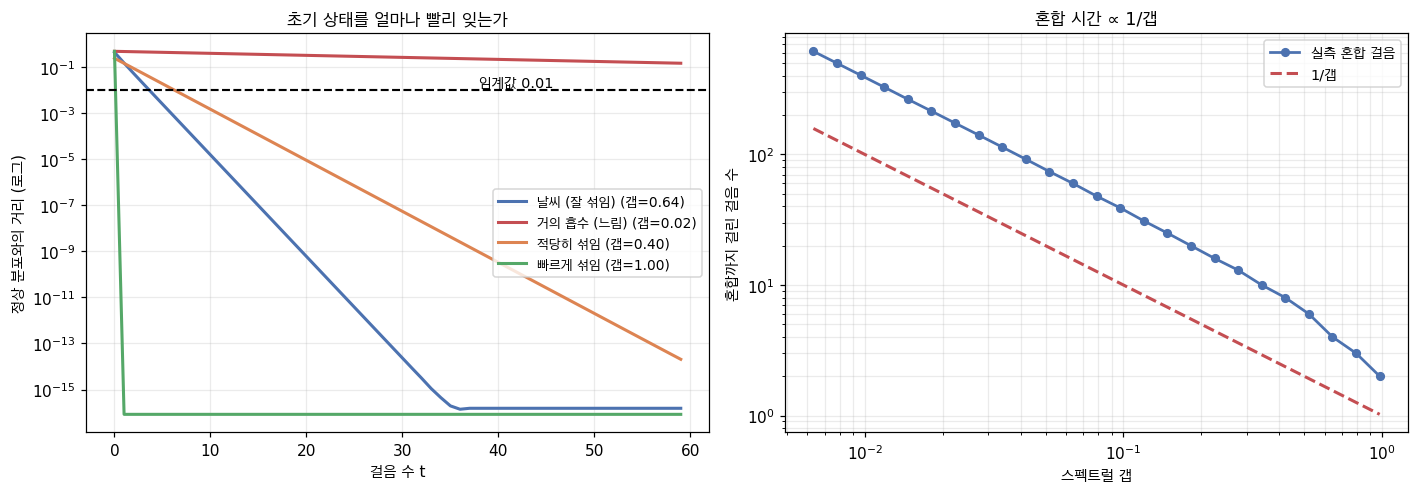

로그-로그 기울기: -1.084   (1/갭이면 -1이어야 합니다)

왼쪽 그림에서 각 선의 '기울기'가 곧 수렴 속도입니다.
빨간 선(갭 0.02)은 거의 평평합니다 — 100걸음을 걸어도 초기 상태를 못 잊습니다.

💡 실무: MCMC를 돌리기 전에 스펙트럴 갭을 확인하세요.
   갭이 0.01이면 샘플 하나를 얻는 데 100걸음이 필요하다는 뜻입니다.


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

for (name, P_), color in zip(chains.items(), ["#4c72b0", "#c44e52", "#dd8452", "#55a868"]):
    pi_ = MarkovChain(P_).stationary_eig()
    p = np.zeros(len(P_)); p[0] = 1.0
    tvs = []
    for t in range(60):
        tvs.append(max(total_variation(p, pi_), 1e-17))
        p = p @ P_
    gap, vals = spectral_gap(P_)
    ax1.semilogy(tvs, lw=2, color=color, label=f"{name} (갭={gap:.2f})")
ax1.axhline(0.01, color="black", ls="--", lw=1.4)
ax1.text(38, 0.014, "임계값 0.01", fontsize=9.5)
ax1.set_xlabel("걸음 수 t"); ax1.set_ylabel("정상 분포와의 거리 (로그)")
ax1.set_title("초기 상태를 얼마나 빨리 잊는가", fontsize=11.5)
ax1.legend(fontsize=9); ax1.grid(alpha=0.25, which="both")

# 갭 vs 혼합 시간
gaps, mixes = [], []
for eps in np.logspace(-2.5, -0.31, 25):
    P_ = np.array([[1-eps, eps], [eps, 1-eps]])
    g, _ = spectral_gap(P_)
    pi_ = np.array([0.5, 0.5])
    st = mixing_steps(P_, pi_, max_steps=200000)
    if st:
        gaps.append(g); mixes.append(st)
ax2.loglog(gaps, mixes, "o-", ms=5, color="#4c72b0", lw=1.8, label="실측 혼합 걸음")
ax2.loglog(gaps, [1/g for g in gaps], "--", lw=2, color="#c44e52", label="1/갭")
ax2.set_xlabel("스펙트럴 갭"); ax2.set_ylabel("혼합까지 걸린 걸음 수")
ax2.set_title("혼합 시간 ∝ 1/갭", fontsize=11.5)
ax2.legend(fontsize=9.5); ax2.grid(alpha=0.25, which="both")

plt.tight_layout()
plt.show()

slope = np.polyfit(np.log(gaps), np.log(mixes), 1)[0]
print(f"로그-로그 기울기: {slope:.3f}   (1/갭이면 -1이어야 합니다)")
print("\n왼쪽 그림에서 각 선의 '기울기'가 곧 수렴 속도입니다.")
print("빨간 선(갭 0.02)은 거의 평평합니다 — 100걸음을 걸어도 초기 상태를 못 잊습니다.")
print("\n💡 실무: MCMC를 돌리기 전에 스펙트럴 갭을 확인하세요.")
print("   갭이 0.01이면 샘플 하나를 얻는 데 100걸음이 필요하다는 뜻입니다.")

## 7️⃣ 흡수 상태

**한 번 들어가면 절대 못 나오는 상태**를 흡수 상태라고 합니다. `P[i][i] = 1` 이죠.

흡수 마르코프 연쇄는 **끝이 있는 과정**을 모형화합니다.

| 도메인 | 흡수 상태 |
| --- | --- |
| 게임 | 승리 / 패배 |
| 고객 분석 | 이탈(churn) |
| **언어모델** | **EOS(문장 끝) 토큰** |
| 강화학습 | 종료 상태 |

흡수 상태가 있으면 **정상 분포가 흡수 상태에 전부 몰립니다.**
그래서 흥미로운 질문이 달라집니다.

- **흡수될 때까지 몇 걸음 걸리나?** (기대 흡수 시간)
- **어느 흡수 상태로 갈 확률이 얼마인가?** (흡수 확률)

이건 선형 시스템으로 풀립니다. 전이 행렬을 이렇게 쪼개면:

$$P = \begin{pmatrix} Q & R \\ 0 & I \end{pmatrix}$$

`Q`는 비흡수 상태끼리의 전이입니다. 그러면 **기본 행렬** `N = (I − Q)⁻¹`이고,
`N`의 행 합이 **기대 흡수 시간**, `NR`이 **흡수 확률**입니다.

> 🔗 **7주차의 `(I − Q)x = b` 선형 시스템 풀이가 여기서 쓰입니다.**

In [12]:
def absorbing_analysis(P, absorbing):
    n = len(P)
    trans = [i for i in range(n) if i not in absorbing]
    Q = P[np.ix_(trans, trans)]
    R = P[np.ix_(trans, absorbing)]
    N = np.linalg.inv(np.eye(len(trans)) - Q)      # 기본 행렬
    return trans, N.sum(axis=1), N @ R

# 도박꾼의 파산을 흡수 연쇄로 정확히 풀어 봅니다 (2절은 시뮬레이션이었죠)
N_goal = 20
P_g = np.zeros((N_goal+1, N_goal+1))
P_g[0, 0] = 1.0                                     # 파산 = 흡수
P_g[N_goal, N_goal] = 1.0                           # 목표 달성 = 흡수
for k in range(1, N_goal):
    P_g[k, k+1] = 0.5
    P_g[k, k-1] = 0.5

trans, exp_time, abs_prob = absorbing_analysis(P_g, [0, N_goal])
print(f"도박꾼의 파산 (목표 {N_goal}, 공정한 게임) — 정확해\n")
print(f"{'시작 자금':>10}{'목표 도달 확률':>16}{'이론 k/N':>12}{'기대 게임 수':>16}{'이론 k(N-k)':>14}")
print("-" * 70)
for idx, k in enumerate(trans):
    if k in [1, 5, 10, 15, 19]:
        print(f"{k:>10}{abs_prob[idx, 1]:>16.6f}{k/N_goal:>12.6f}"
              f"{exp_time[idx]:>16.2f}{k*(N_goal-k):>14}")

print("\n=> 도달 확률은 정확히 k/N, 기대 게임 수는 정확히 k(N-k)입니다.")
print("   2절의 시뮬레이션이 근사했던 값을 여기서는 선형 시스템으로 정확히 구했습니다.")
print(f"\n   재미있는 점: 자금 {N_goal//2}에서 시작하면 기대 게임 수가 "
      f"{N_goal//2*(N_goal-N_goal//2)}판으로 가장 깁니다.")
print("   양쪽 벽에서 가장 멀기 때문입니다.")

print("\n[🏭 언어모델 비유 — EOS 토큰이 흡수 상태입니다]")
# 상태: 0=문장 시작, 1=중간, 2=EOS(흡수)
P_lm = np.array([[0.1, 0.85, 0.05],
                 [0.0, 0.90, 0.10],
                 [0.0, 0.00, 1.00]])
tr_lm, time_lm, _ = absorbing_analysis(P_lm, [2])
print(f"  EOS 전이 확률 10%일 때 기대 생성 길이: {time_lm[0]:.2f} 토큰")
for eos_p in [0.02, 0.05, 0.1, 0.3]:
    P_t = np.array([[0.1, 0.9-eos_p, eos_p], [0.0, 1-eos_p, eos_p], [0.0, 0.0, 1.0]])
    _, t_, _ = absorbing_analysis(P_t, [2])
    print(f"  EOS 확률 {eos_p:>4.0%} -> 기대 길이 {t_[0]:>6.1f} 토큰  (대략 1/p = {1/eos_p:.1f})")
print("\n  => EOS 확률이 낮으면 생성이 길어집니다. 기하분포의 기대값 1/p 를 따릅니다.")
print("     '모델이 말을 안 끝낸다'는 현상의 수학적 정체입니다.")

도박꾼의 파산 (목표 20, 공정한 게임) — 정확해

     시작 자금        목표 도달 확률      이론 k/N         기대 게임 수     이론 k(N-k)
----------------------------------------------------------------------
         1        0.050000    0.050000           19.00            19
         5        0.250000    0.250000           75.00            75
        10        0.500000    0.500000          100.00           100
        15        0.750000    0.750000           75.00            75
        19        0.950000    0.950000           19.00            19

=> 도달 확률은 정확히 k/N, 기대 게임 수는 정확히 k(N-k)입니다.
   2절의 시뮬레이션이 근사했던 값을 여기서는 선형 시스템으로 정확히 구했습니다.

   재미있는 점: 자금 10에서 시작하면 기대 게임 수가 100판으로 가장 깁니다.
   양쪽 벽에서 가장 멀기 때문입니다.

[🏭 언어모델 비유 — EOS 토큰이 흡수 상태입니다]
  EOS 전이 확률 10%일 때 기대 생성 길이: 10.56 토큰
  EOS 확률   2% -> 기대 길이   50.0 토큰  (대략 1/p = 50.0)
  EOS 확률   5% -> 기대 길이   20.0 토큰  (대략 1/p = 20.0)
  EOS 확률  10% -> 기대 길이   10.0 토큰  (대략 1/p = 10.0)
  EOS 확률  30% -> 기대 길이    3.3 토큰  (대략 1/p = 3.3)

  => EOS 확률이 낮으면 생성이 길어집니다. 기하분포의 기대값 1/p 를 따릅니다.
 

## 8️⃣ 🔨 랑주뱅 동역학 — 노이즈를 더한 경사하강

경사하강법은 함수의 **최솟값**을 찾습니다.
**랑주뱅 동역학**은 `exp(−U(x)/T)`에 **비례하는 확률분포**를 찾습니다.

$$x_{t+1} = x_t - dt\cdot\nabla U(x_t) + \sqrt{2T\,dt}\cdot z_t, \qquad z_t \sim N(0,1)$$

입자에 **두 힘**이 작용합니다.

1. **기울기 힘** `−dt·∇U` → 낮은 에너지 쪽으로 밀어냅니다 (= 경사하강)
2. **무작위 힘** `√(2T·dt)·z` → 아무 방향으로나 밀어냅니다 (= 탐색)

| 온도 `T` | 동작 |
| --- | --- |
| `T = 0` | **순수한 경사하강** — 가장 가까운 최솟값에 멈춥니다 |
| 낮은 `T` | 최솟값 주변에서 조금씩 떨림 |
| 적당한 `T` | 골짜기 사이를 오가며 **분포 전체를 탐색** |
| 높은 `T` | 거의 랜덤 워크 — 에너지 지형을 무시 |

### 🔑 노이즈 항의 계수가 왜 하필 `√(2T·dt)` 인가

이 계수여야만 정상 분포가 정확히 **볼츠만 분포** `p(x) ∝ exp(−U(x)/T)`가 됩니다.
아무 노이즈나 더하면 안 되고, **기울기 힘과 정확히 균형을 이루는 크기**여야 해요.

> 🔗 **7주차 볼록 최적화와 연결됩니다.**
> 거기서 "SGD의 노이즈가 평평한 최솟값을 선호한다"고 했죠.
> 랑주뱅 동역학이 그 현상의 **정확한 수학적 모형**입니다.

In [13]:
def langevin(grad_U, x0, dt, T, n_steps, seed=None):
    rng = np.random.default_rng(seed)
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    for _ in range(n_steps):
        x = x - dt * grad_U(x) + math.sqrt(2 * T * dt) * rng.normal(size=x.shape)
        traj.append(x.copy())
    return np.array(traj)

# 연습 4 — 이중 우물 U(x) = (x² - 1)²
U = lambda x: (x**2 - 1)**2
grad_U = lambda x: 4 * x * (x**2 - 1)

print("이중 우물 U(x) = (x² - 1)²  — 최솟값이 x = ±1 두 곳\n")
print(f"{'온도 T':>10}{'우물 전환 횟수':>16}{'왼쪽 우물 비율':>16}{'표본 표준편차':>16}")
print("-" * 60)
for T in [0.02, 0.05, 0.1, 0.3, 1.0]:
    traj = langevin(grad_U, [1.0], dt=0.01, T=T, n_steps=200000, seed=1)[:, 0]
    burn = traj[20000:]
    side = np.sign(burn)
    switches = int(np.sum(np.abs(np.diff(side)) > 1))     # 부호가 바뀐 횟수
    print(f"{T:>10.2f}{switches:>16,}{np.mean(burn < 0):>15.1%}{burn.std():>16.4f}")

print("\n=> 온도가 낮으면 한 우물에 갇힙니다 (전환 0회).")
print("   온도를 올리면 두 우물을 오갑니다. 그리고 좌우 비율이 50%에 가까워집니다.")
print("   대칭인 퍼텐셜이니 이론적으로 50:50이어야 하죠.")

print("\n[🔑 랑주뱅이 정말 볼츠만 분포를 만드는가]")
print("  ⚠️ 단, 우물 사이를 오갈 만큼 온도가 충분해야 합니다(위 표에서 T ≥ 0.3).")
print("     온도가 낮으면 표본이 한쪽 우물에만 쌓여서 이론과 안 맞습니다.\n")
print(f"{'온도 T':>8}{'평균':>12}{'좌우 비율':>14}{'볼츠만과의 최대 차이':>22}{'판정':>10}")
print("-" * 68)
for T in [0.15, 0.3, 0.5, 0.8]:
    traj = langevin(grad_U, [0.0], dt=0.005, T=T, n_steps=600000, seed=3)[:, 0][50000:]
    hist, edges = np.histogram(traj, bins=100, range=(-2.5, 2.5), density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    theory = np.exp(-U(centers) / T); theory /= np.trapz(theory, centers)
    err = np.abs(hist - theory).max()
    ok = "✅ 일치" if err < 0.1 else "❌ 미수렴"
    print(f"{T:>8.2f}{traj.mean():>+12.4f}{np.mean(traj < 0):>13.1%}{err:>22.4f}{ok:>10}")

print("\n  => T = 0.15에서는 표본 평균이 0이 아니고 좌우 비율도 15% 대입니다.")
print("     '수렴한 것처럼 보이지만 실은 반쪽만 탐색한' 전형적인 실패입니다.")
print("     T ≥ 0.3 이면 이론 볼츠만 분포와 잘 맞습니다.")
print("\n  💡 노이즈 계수 √(2T·dt)가 정확해야 이렇게 됩니다. 계수가 틀리면 엉뚱한 분포로 갑니다.")

이중 우물 U(x) = (x² - 1)²  — 최솟값이 x = ±1 두 곳

      온도 T        우물 전환 횟수        왼쪽 우물 비율         표본 표준편차
------------------------------------------------------------
      0.02               0           0.0%          0.0513
      0.05               0           0.0%          0.0823
      0.10               0           0.0%          0.1205
      0.30             340          55.6%          0.9424
      1.00           3,919          49.3%          0.9061

=> 온도가 낮으면 한 우물에 갇힙니다 (전환 0회).
   온도를 올리면 두 우물을 오갑니다. 그리고 좌우 비율이 50%에 가까워집니다.
   대칭인 퍼텐셜이니 이론적으로 50:50이어야 하죠.

[🔑 랑주뱅이 정말 볼츠만 분포를 만드는가]
  ⚠️ 단, 우물 사이를 오갈 만큼 온도가 충분해야 합니다(위 표에서 T ≥ 0.3).
     온도가 낮으면 표본이 한쪽 우물에만 쌓여서 이론과 안 맞습니다.

    온도 T          평균         좌우 비율           볼츠만과의 최대 차이        판정
--------------------------------------------------------------------
    0.15     +0.6831        14.7%                0.9779     ❌ 미수렴
    0.30     -0.0388        52.1%                0.0563      ✅ 일치
    0.50     -0.0064        50.5%                0

### 🖼️ 그림 5 — 온도가 바꾸는 것

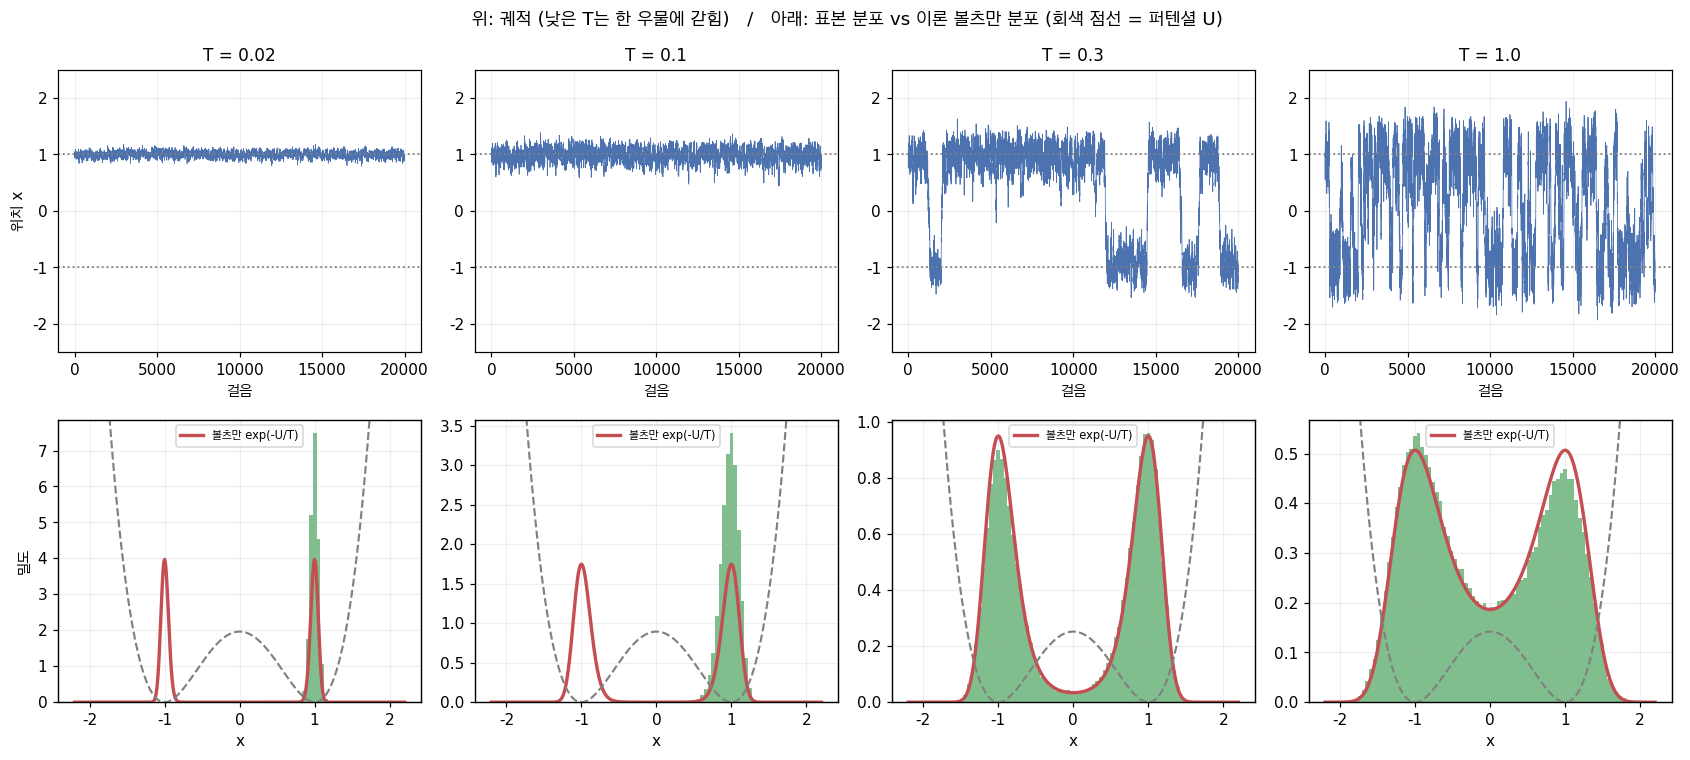

T=0.02: 궤적이 x=1 근처에만 머뭅니다. 히스토그램도 한쪽에만 있죠.
        이론(빨강)은 양쪽 대칭인데 실측은 반쪽만 — '수렴하지 않았다'는 뜻입니다.
T=0.3~1.0: 두 우물을 활발히 오가고, 히스토그램이 이론 곡선에 잘 맞습니다.

💡 이게 MCMC의 고질적 문제입니다 — 낮은 온도에서 표본은 '그럴듯해' 보이지만
   실제로는 분포의 절반만 탐색한 것일 수 있습니다. 6주차 MCMC 진단이 필요한 이유예요.


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(15.5, 7))
xs = np.linspace(-2.2, 2.2, 400)

for col, T in enumerate([0.02, 0.1, 0.3, 1.0]):
    traj = langevin(grad_U, [1.0], dt=0.01, T=T, n_steps=120000, seed=2)[:, 0]
    burn = traj[10000:]

    ax = axes[0][col]
    ax.plot(traj[:20000], lw=0.5, color="#4c72b0")
    ax.axhline(1, color="gray", ls=":", lw=1.2)
    ax.axhline(-1, color="gray", ls=":", lw=1.2)
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(f"T = {T}", fontsize=11)
    ax.set_xlabel("걸음")
    if col == 0:
        ax.set_ylabel("위치 x")
    ax.grid(alpha=0.2)

    ax = axes[1][col]
    ax.hist(burn, bins=90, range=(-2.2, 2.2), density=True, color="#55a868", alpha=0.75)
    b = np.exp(-U(xs) / T); b /= np.trapz(b, xs)
    ax.plot(xs, b, lw=2.2, color="#c44e52", label="볼츠만 exp(-U/T)")
    ax2 = ax.twinx()
    ax2.plot(xs, U(xs), lw=1.4, color="gray", ls="--")
    ax2.set_ylim(0, 4); ax2.set_yticks([])
    ax.set_xlabel("x")
    if col == 0:
        ax.set_ylabel("밀도")
    ax.legend(fontsize=7.5, loc="upper center")
    ax.grid(alpha=0.2)

plt.suptitle("위: 궤적 (낮은 T는 한 우물에 갇힘)   /   아래: 표본 분포 vs 이론 볼츠만 분포 (회색 점선 = 퍼텐셜 U)",
             fontsize=12)
plt.tight_layout()
plt.show()

print("T=0.02: 궤적이 x=1 근처에만 머뭅니다. 히스토그램도 한쪽에만 있죠.")
print("        이론(빨강)은 양쪽 대칭인데 실측은 반쪽만 — '수렴하지 않았다'는 뜻입니다.")
print("T=0.3~1.0: 두 우물을 활발히 오가고, 히스토그램이 이론 곡선에 잘 맞습니다.")
print("\n💡 이게 MCMC의 고질적 문제입니다 — 낮은 온도에서 표본은 '그럴듯해' 보이지만")
print("   실제로는 분포의 절반만 탐색한 것일 수 있습니다. 6주차 MCMC 진단이 필요한 이유예요.")

## 9️⃣ 🏭 디퓨전 모델 — 순방향과 역방향

이제 모든 조각이 만납니다.

### 📐 순방향 과정 — 알려진 마르코프 연쇄

$$q(x_t \mid x_{t-1}) = \mathcal{N}\big(x_t;\ \sqrt{1-\beta_t}\,x_{t-1},\ \beta_t I\big)$$

즉 `x_t = √(1−β_t)·x_{t-1} + √(β_t)·ε` 입니다.

- **마르코프 연쇄**입니다 — `x_t`는 `x_{t-1}`에만 의존합니다 (4절)
- **브라운 운동과 같은 구조**입니다 — 정규 노이즈를 누적합니다 (3절)
- `T`단계 뒤 `x_T ≈ N(0, I)` — 완전한 잡음

### 🔑 닫힌 형태 — 아무 단계로나 한 번에 점프

$$x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\varepsilon, \qquad
\bar{\alpha}_t = \prod_{s=1}^t (1-\beta_s)$$

**1000단계를 밟지 않고 한 번에 갈 수 있습니다.** 학습이 가능한 이유예요.
무작위 `t`를 뽑아서 바로 `x_t`를 만들고 손실을 계산합니다.

### 📐 역방향 과정 — 학습되는 마르코프 연쇄

신경망이 **각 단계에서 더해진 노이즈 `ε`를 예측**하도록 학습합니다.
그리고 그걸 빼면 한 단계 되돌릴 수 있죠.

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(x_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\varepsilon_\theta(x_t, t)\Big) + \sigma_t z$$

**생성의 매 단계가 학습된 마르코프 연쇄의 한 걸음**입니다.

> 🔗 8주차 푸리에 노트북에서 순방향 확산을 이미 봤습니다.
> 여기서는 **역방향까지** 만들어 보겠습니다.

In [15]:
# 순방향 확산 + 아주 단순한 역방향 (연습 5)
T_steps = 200
betas = np.linspace(1e-4, 0.02, T_steps)
alphas = 1 - betas
alpha_bars = np.cumprod(alphas)

# 원본 '데이터': 1D 사인 신호
L = 200
t_grid = np.linspace(0, 4*np.pi, L)
x0 = np.sin(t_grid) + 0.4*np.sin(3*t_grid)

def forward(x0, t, rng):
    ab = alpha_bars[t]
    eps = rng.normal(size=x0.shape)
    return math.sqrt(ab)*x0 + math.sqrt(1-ab)*eps, eps

print("순방향 확산 — 신호가 노이즈에 잠깁니다\n")
print(f"{'단계 t':>8}{'ᾱ_t':>12}{'신호 비중':>12}{'노이즈 비중':>14}{'원본과의 상관':>16}")
print("-" * 66)
rng = np.random.default_rng(0)
for t in [0, 25, 50, 100, 150, 199]:
    xt, _ = forward(x0, t, np.random.default_rng(1))
    print(f"{t:>8}{alpha_bars[t]:>12.5f}{math.sqrt(alpha_bars[t]):>12.4f}"
          f"{math.sqrt(1-alpha_bars[t]):>14.4f}{np.corrcoef(x0, xt)[0,1]:>16.4f}")

print("\n[마르코프 성질 확인] 한 단계씩 100번 밟기 vs 닫힌 형태로 한 번에 점프")
print("  한 번만 돌리면 노이즈 실현값 때문에 흔들리므로 60회 반복해 평균 냅니다.\n")
v_step, v_jump = [], []
for sd in range(60):
    ra = np.random.default_rng(sd)
    xs_ = x0.copy()
    for t in range(100):
        xs_ = math.sqrt(alphas[t])*xs_ + math.sqrt(betas[t])*ra.normal(size=L)
    v_step.append(xs_.var())
    v_jump.append(forward(x0, 99, np.random.default_rng(1000+sd))[0].var())
theory_var = alpha_bars[99]*x0.var() + (1-alpha_bars[99])
print(f"  단계별 100회 진행 : 분산 평균 {np.mean(v_step):.4f} (±{np.std(v_step):.4f})")
print(f"  닫힌 형태 점프    : 분산 평균 {np.mean(v_jump):.4f} (±{np.std(v_jump):.4f})")
print(f"  이론값 ᾱ·Var(x₀)+(1-ᾱ) = {theory_var:.4f}")
print("\n  => 두 방식의 평균이 이론값 주위에서 일치합니다 (편차 범위 안).")
print("     노이즈 실현값은 매번 다르지만 통계적 성질이 같다는 뜻이고,")
print("     그래서 1000단계를 밟지 않고 한 번에 점프해서 학습할 수 있습니다.")

순방향 확산 — 신호가 노이즈에 잠깁니다

    단계 t         ᾱ_t       신호 비중        노이즈 비중         원본과의 상관
------------------------------------------------------------------
       0     0.99990      0.9999        0.0100          0.9999
      25     0.96548      0.9826        0.1858          0.9744
      50     0.87562      0.9357        0.3527          0.9078
     100     0.59640      0.7723        0.6353          0.7011
     150     0.31555      0.5617        0.8273          0.4767
     199     0.13218      0.3636        0.9316          0.2918

[마르코프 성질 확인] 한 단계씩 100번 밟기 vs 닫힌 형태로 한 번에 점프
  한 번만 돌리면 노이즈 실현값 때문에 흔들리므로 60회 반복해 평균 냅니다.

  단계별 100회 진행 : 분산 평균 0.7303 (±0.0631)
  닫힌 형태 점프    : 분산 평균 0.7496 (±0.0544)
  이론값 ᾱ·Var(x₀)+(1-ᾱ) = 0.7452

  => 두 방식의 평균이 이론값 주위에서 일치합니다 (편차 범위 안).
     노이즈 실현값은 매번 다르지만 통계적 성질이 같다는 뜻이고,
     그래서 1000단계를 밟지 않고 한 번에 점프해서 학습할 수 있습니다.


In [16]:
# 🔨 역방향 — '완벽한 노이즈 예측기'가 있다고 가정하고 되돌려 봅니다
def reverse_diffuse(x_T, true_eps_fn, seed=0):
    # true_eps_fn(x_t, t) 가 그 단계의 노이즈를 알려준다고 가정 (이상적인 신경망)
    rng = np.random.default_rng(seed)
    x = x_T.copy()
    traj = {T_steps-1: x.copy()}
    for t in range(T_steps-1, -1, -1):
        eps = true_eps_fn(x, t)
        coef = betas[t] / math.sqrt(1 - alpha_bars[t])
        mean = (x - coef*eps) / math.sqrt(alphas[t])
        if t > 0:
            sigma = math.sqrt(betas[t])
            x = mean + sigma*rng.normal(size=x.shape)
        else:
            x = mean
        if t in (150, 100, 50, 10, 0):
            traj[t] = x.copy()
    return x, traj

# '완벽한 예측기': x_t = √ᾱ x₀ + √(1-ᾱ) ε 이므로 x₀를 알면 ε를 역산할 수 있습니다
def oracle_eps(x_t, t):
    return (x_t - math.sqrt(alpha_bars[t]) * x0) / math.sqrt(1 - alpha_bars[t])

x_T, _ = forward(x0, T_steps-1, np.random.default_rng(21))
x_rec, traj_rev = reverse_diffuse(x_T, oracle_eps, seed=4)

print("역방향 확산 — 노이즈에서 신호를 복원합니다\n")
print(f"  시작(x_T)과 원본의 상관: {np.corrcoef(x0, x_T)[0,1]:+.4f}  (거의 무관)")
print(f"  복원 결과와 원본의 상관: {np.corrcoef(x0, x_rec)[0,1]:+.4f}")
print(f"  복원 오차 (RMSE)       : {np.sqrt(((x_rec-x0)**2).mean()):.4f}")
print(f"  원본 신호의 표준편차   : {x0.std():.4f}")

print("\n⚠️ 중요한 단서: 여기서는 '완벽한 노이즈 예측기'를 썼습니다.")
print("   x₀를 이미 알고 있으니 ε를 정확히 역산할 수 있었죠 — 일종의 반칙입니다.")
print("   진짜 디퓨전 모델은 이 ε를 신경망으로 '학습'합니다. 그게 어려운 부분이고요.")
print("   이 데모가 보여 주는 건 '역방향 마르코프 연쇄의 수식이 실제로 작동한다'는 것입니다.")

print("\n[노이즈 예측기를 망가뜨려 보면 — 무엇이 치명적인가]")
print(f"{'예측기':<32}{'복원 상관':>12}{'RMSE':>10}{'판정':>12}")
print("-" * 68)
predictors = [
    ("완벽 (오라클)", oracle_eps),
    ("무작위 오차 σ=1 추가", lambda xt, t, r=np.random.default_rng(9):
        oracle_eps(xt, t) + r.normal(size=xt.shape)),
    ("예측 크기 30% 과소", lambda xt, t: oracle_eps(xt, t) * 0.7),
    ("예측 크기 2배 과대", lambda xt, t: oracle_eps(xt, t) * 2.0),
    ("아무것도 안 함 (ε=0)", lambda xt, t: np.zeros_like(xt)),
    ("완전 무작위 예측", lambda xt, t, r=np.random.default_rng(3): r.normal(size=xt.shape)),
]
for nm, fn in predictors:
    xr, _ = reverse_diffuse(x_T, fn, seed=4)
    corr = np.corrcoef(x0, xr)[0, 1]
    rmse = np.sqrt(((xr - x0)**2).mean())
    verdict = "✅ 복원" if rmse < 0.1 else "❌ 실패"
    print(f"{nm:<32}{corr:>+12.4f}{rmse:>10.4f}{verdict:>12}")

print(f"\n원본 신호의 표준편차 {x0.std():.4f} — RMSE가 이 값 수준이면 복원 실패입니다.")
print("\n💡 흥미로운 결과입니다. 예측에 노이즈를 크게 더하거나 크기를 2배로 틀려도")
print("   복원이 거의 완벽합니다. 두 가지 이유 때문입니다.")
print("   ① 매 스텝 '현재 x'로부터 다시 예측하므로 오차가 자기 교정됩니다.")
print("   ② 200스텝에 걸쳐 평균 0인 오차가 상쇄됩니다.")
print("\n   반면 예측을 아예 안 하거나 정보가 전혀 없는 예측을 하면 완전히 실패합니다.")
print("   => 디퓨전이 실무에서 잘 작동하는 이유가 여기 있습니다.")
print("      신경망의 예측이 '완벽할' 필요는 없고 '정보를 담고 있으면' 됩니다.")

역방향 확산 — 노이즈에서 신호를 복원합니다

  시작(x_T)과 원본의 상관: +0.2953  (거의 무관)
  복원 결과와 원본의 상관: +1.0000
  복원 오차 (RMSE)       : 0.0000
  원본 신호의 표준편차   : 0.7597

⚠️ 중요한 단서: 여기서는 '완벽한 노이즈 예측기'를 썼습니다.
   x₀를 이미 알고 있으니 ε를 정확히 역산할 수 있었죠 — 일종의 반칙입니다.
   진짜 디퓨전 모델은 이 ε를 신경망으로 '학습'합니다. 그게 어려운 부분이고요.
   이 데모가 보여 주는 건 '역방향 마르코프 연쇄의 수식이 실제로 작동한다'는 것입니다.

[노이즈 예측기를 망가뜨려 보면 — 무엇이 치명적인가]
예측기                                    복원 상관      RMSE          판정
--------------------------------------------------------------------
완벽 (오라클)                             +1.0000    0.0000        ✅ 복원
무작위 오차 σ=1 추가                        +0.9999    0.0099        ✅ 복원
예측 크기 30% 과소                         +1.0000    0.0068        ✅ 복원
예측 크기 2배 과대                          +0.9998    0.0162        ✅ 복원
아무것도 안 함 (ε=0)                       +0.2205    3.6203        ❌ 실패
완전 무작위 예측                            +0.2297    3.6232        ❌ 실패

원본 신호의 표준편차 0.7597 — RMSE가 이 값 수준이면 복원 실패입니다.

💡 흥미로운 결과입니다. 예측에 노이즈를 크게 더하거나 크기를 2배로 틀려도
   복원이 거의 완벽

### 🖼️ 그림 6 — 순방향과 역방향

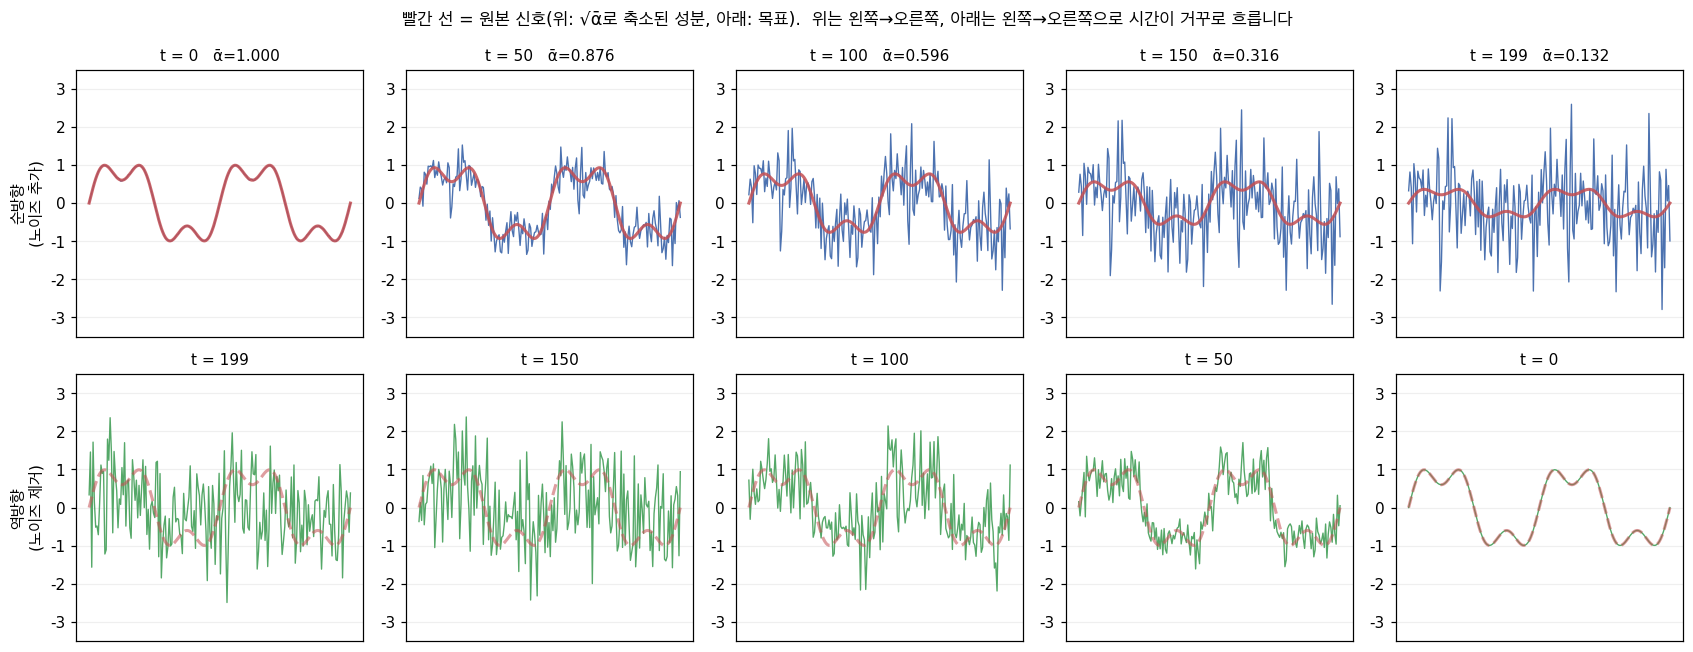

위 줄: 사인파가 점점 잡음에 묻힙니다.
아래 줄: 순수 잡음(t=199)에서 시작해 점점 사인파가 드러납니다.

두 줄이 '같은 마르코프 연쇄를 양방향으로 돌린 것'입니다.
순방향은 우리가 정의한 것이고, 역방향은 신경망이 배우는 것입니다.


In [17]:
fig, axes = plt.subplots(2, 5, figsize=(15.5, 6))

# 위: 순방향 (데이터 -> 노이즈)
for col, t in enumerate([0, 50, 100, 150, 199]):
    xt, _ = forward(x0, t, np.random.default_rng(1))
    axes[0][col].plot(xt, lw=0.9, color="#4c72b0")
    axes[0][col].plot(math.sqrt(alpha_bars[t])*x0, lw=2, color="#c44e52", alpha=0.85)
    axes[0][col].set_ylim(-3.5, 3.5); axes[0][col].set_xticks([])
    axes[0][col].set_title(f"t = {t}   ᾱ={alpha_bars[t]:.3f}", fontsize=10)
    axes[0][col].grid(alpha=0.2)
axes[0][0].set_ylabel("순방향\n(노이즈 추가)", fontsize=10.5)

# 아래: 역방향 (노이즈 -> 데이터)
for col, t in enumerate([199, 150, 100, 50, 0]):
    axes[1][col].plot(traj_rev[t], lw=0.9, color="#55a868")
    axes[1][col].plot(x0, lw=2, color="#c44e52", alpha=0.55, ls="--")
    axes[1][col].set_ylim(-3.5, 3.5); axes[1][col].set_xticks([])
    axes[1][col].set_title(f"t = {t}", fontsize=10)
    axes[1][col].grid(alpha=0.2)
axes[1][0].set_ylabel("역방향\n(노이즈 제거)", fontsize=10.5)

plt.suptitle("빨간 선 = 원본 신호(위: √ᾱ로 축소된 성분, 아래: 목표).  "
             "위는 왼쪽→오른쪽, 아래는 왼쪽→오른쪽으로 시간이 거꾸로 흐릅니다", fontsize=11.5)
plt.tight_layout()
plt.show()

print("위 줄: 사인파가 점점 잡음에 묻힙니다.")
print("아래 줄: 순수 잡음(t=199)에서 시작해 점점 사인파가 드러납니다.")
print("\n두 줄이 '같은 마르코프 연쇄를 양방향으로 돌린 것'입니다.")
print("순방향은 우리가 정의한 것이고, 역방향은 신경망이 배우는 것입니다.")

## 🔟 🏭 언어모델의 토큰 생성도 마르코프 과정입니다

언어모델의 토큰 생성은 **근사적으로 마르코프 과정**입니다.
현재 문맥이 주어지면 모델이 다음 토큰의 분포를 출력하죠.

$$P(\text{token}_i) = \frac{\exp(z_i/\tau)}{\sum_j \exp(z_j/\tau)}$$

**온도 `τ`** 가 분포의 뾰족함을 조절합니다 (6주차 샘플링에서 자세히 다뤘습니다).

> ⚠️ **엄밀히 말하면 마르코프가 아닙니다.**
> 트랜스포머는 전체 문맥을 봅니다. "상태 = 마지막 토큰"으로 보면 마르코프 성질이 깨져요.
> 다만 **"상태 = 전체 문맥"** 으로 정의하면 마르코프 연쇄가 맞습니다.
> 상태 공간이 어마어마하게 커질 뿐이죠.

### 🔨 진짜 마르코프 연쇄로 텍스트를 생성해 봅시다 (연습 2)

**단어 단위 마르코프 연쇄**를 만들어 보면 두 가지가 동시에 보입니다.

1. **마르코프 연쇄가 그럴듯한 국소 구조를 만들어 낸다** — 인접한 단어 쌍은 자연스럽습니다
2. **그런데 긴 범위 일관성이 없다** — 문장이 산으로 갑니다

**이게 정확히 트랜스포머가 해결한 문제입니다.**

In [18]:
corpus_lines = [
    "고양이는 창가에 앉아 밖을 바라본다 창밖에는 비가 내린다 비가 내리면 고양이는 잠을 잔다",
    "강아지는 마당에서 뛰논다 마당에는 나무가 있다 나무 아래에서 강아지는 잠을 잔다",
    "비가 내리면 마당은 젖는다 젖은 마당에서 강아지는 뛰논다 고양이는 비를 싫어한다",
    "창가에 앉은 고양이는 강아지를 바라본다 강아지는 고양이를 바라본다",
]
corpus = " ".join(corpus_lines).split()

def build_chain(words):
    states = sorted(set(words))
    idx = {w: i for i, w in enumerate(states)}
    n = len(states)
    counts = np.zeros((n, n))
    for a, b in zip(words[:-1], words[1:]):
        counts[idx[a], idx[b]] += 1
    rows = counts.sum(1, keepdims=True)
    P = np.where(rows > 0, counts / np.maximum(rows, 1), 1.0/n)   # 막다른 단어는 균등
    return P, states, idx

P_text, states, idx = build_chain(corpus)
print(f"말뭉치: {len(corpus)}단어, 서로 다른 단어 {len(states)}개")
print(f"전이 행렬 크기: {P_text.shape}\n")

mc_text = MarkovChain(P_text)
print("생성 결과 (같은 단어로 시작해도 매번 달라집니다)")
start = idx["고양이는"]
for s in range(4):
    seq = mc_text.simulate(start, 11, seed=s)
    print(f"  {s+1}: " + " ".join(states[i] for i in seq))

print("\n[전이 확률 들여다보기] '고양이는' 다음에 오는 단어")
row = P_text[idx["고양이는"]]
for j in np.argsort(row)[::-1][:5]:
    if row[j] > 0:
        print(f"  {states[j]:<10} {row[j]:.3f}")

print("\n💡 관찰")
print("  ✅ 인접한 단어 쌍은 자연스럽습니다 (말뭉치에 있던 조합이니까요)")
print("  ❌ 문장 전체는 앞뒤가 안 맞습니다 — 두 단어 전은 이미 잊었으니까요")
print("\n  이게 마르코프 성질의 대가입니다. '기억이 없다'는 게 계산은 쉽게 하지만")
print("  긴 범위 일관성을 포기하게 만듭니다.")
print("  트랜스포머의 어텐션은 이 한계를 정면으로 공략한 구조입니다 —")
print("  '전체 문맥을 상태로 삼되, 어디를 볼지 학습으로 정하자'는 발상이죠.")

print("\n[온도가 전이 확률을 바꿉니다 — 6주차 복습]")
logits = np.array([3.2, 2.8, 1.9, 0.6, -1.0])
for tau in [0.2, 1.0, 3.0]:
    z = logits / tau
    p = np.exp(z - z.max()); p /= p.sum()
    ent = -np.sum(p * np.log2(p))
    print(f"  τ={tau:<4}: {np.round(p, 3)}   엔트로피 {ent:.3f} bits")
print("  => 온도를 바꾸는 것 = 마르코프 연쇄의 전이 확률을 바꾸는 것입니다.")

말뭉치: 43단어, 서로 다른 단어 27개
전이 행렬 크기: (27, 27)

생성 결과 (같은 단어로 시작해도 매번 달라집니다)
  1: 고양이는 잠을 잔다 강아지는 고양이를 바라본다 창밖에는 비가 내린다 비가 내린다 비가
  2: 고양이는 잠을 잔다 강아지는 잠을 잔다 강아지는 잠을 잔다 비가 내리면 마당은
  3: 고양이는 비를 싫어한다 창가에 앉아 밖을 바라본다 강아지는 고양이를 바라본다 창밖에는 비가
  4: 고양이는 강아지를 바라본다 창밖에는 비가 내리면 고양이는 비를 싫어한다 창가에 앉아 밖을

[전이 확률 들여다보기] '고양이는' 다음에 오는 단어
  강아지를       0.250
  잠을         0.250
  비를         0.250
  창가에        0.250

💡 관찰
  ✅ 인접한 단어 쌍은 자연스럽습니다 (말뭉치에 있던 조합이니까요)
  ❌ 문장 전체는 앞뒤가 안 맞습니다 — 두 단어 전은 이미 잊었으니까요

  이게 마르코프 성질의 대가입니다. '기억이 없다'는 게 계산은 쉽게 하지만
  긴 범위 일관성을 포기하게 만듭니다.
  트랜스포머의 어텐션은 이 한계를 정면으로 공략한 구조입니다 —
  '전체 문맥을 상태로 삼되, 어디를 볼지 학습으로 정하자'는 발상이죠.

[온도가 전이 확률을 바꿉니다 — 6주차 복습]
  τ=0.2 : [0.88  0.119 0.001 0.    0.   ]   엔트로피 0.541 bits
  τ=1.0 : [0.492 0.33  0.134 0.037 0.007]   엔트로피 1.647 bits
  τ=3.0 : [0.313 0.274 0.203 0.132 0.077]   엔트로피 2.174 bits
  => 온도를 바꾸는 것 = 마르코프 연쇄의 전이 확률을 바꾸는 것입니다.


## 1️⃣1️⃣ 📝 연습문제 (풀이 포함)

1. **랜덤 워크 1000개 × 10000걸음** — 최종 위치 분포가 `N(0, 10000)`인지 확인. *(→ 1절에서 완료)*
2. **마르코프 연쇄 텍스트 생성기** — 말뭉치에서 전이 행렬을 만들고 문장 생성. *(→ 10절에서 완료)*
3. **모의 담금질(simulated annealing)** — 온도를 낮춰가며 다봉 함수의 최솟값 찾기.
4. **온도별 랑주뱅 비교** — 이중 우물에서 우물 사이를 오가는 임계 온도 찾기. *(→ 8절에서 완료)*
5. **순방향 확산 + 간단한 역방향** — 신호를 노이즈로, 다시 신호로. *(→ 9절에서 완료)*

In [19]:
print("=" * 74)
print("연습 3 — 모의 담금질 (Metropolis-Hastings + 온도 스케줄)")
print("=" * 74)

# 지역 최솟값이 많은 함수
def f_multi(x):
    return x**2 / 8 + 3*np.cos(3*x) + 2*np.cos(7*x)

xs_plot = np.linspace(-8, 8, 4000)
true_min_x = xs_plot[int(np.argmin(f_multi(xs_plot)))]
print(f"목표 함수: x²/8 + 3cos(3x) + 2cos(7x)")
print(f"격자 탐색으로 찾은 전역 최솟값: x = {true_min_x:.4f}, f = {f_multi(true_min_x):.4f}\n")

def simulated_annealing(f, x0, T0, T_end, n_steps, step=0.5, seed=0):
    # ⚠️ '지금까지 본 최선'이 아니라 '최종 착지점'을 반환합니다.
    #    최선 기록을 반환하면 고온 탐색이 우연히 최적점을 스쳐가기만 해도 이겨 버려서
    #    '탐색과 정착을 모두 해내는가'라는 원래 질문을 측정하지 못합니다.
    rng = np.random.default_rng(seed)
    x, fx = x0, f(x0)
    for k in range(n_steps):
        T = T0 * (T_end / T0) ** (k / n_steps)          # 지수적 냉각
        cand = x + rng.normal(0, step)
        fc = f(cand)
        if fc < fx or rng.random() < math.exp(-(fc - fx) / max(T, 1e-12)):
            x, fx = cand, fc
    return x, fx

print(f"{'방법':<32}{'최적점 착지율(시드 200)':>24}{'평균 최종 f':>16}")
print("-" * 74)
for name, T0, T_end in [("순수 경사하강 (T≈0 고정)", 1e-12, 1e-12),
                        ("고온 고정 (T=3)", 3.0, 3.0),
                        ("담금질 (T: 3 -> 0.01)", 3.0, 0.01)]:
    hits, fs = 0, []
    for sd in range(200):
        x0 = np.random.default_rng(sd).uniform(-8, 8)
        bx, bf = simulated_annealing(f_multi, x0, T0, T_end, 4000, seed=sd)
        hits += abs(bx - true_min_x) < 0.3
        fs.append(bf)
    print(f"{name:<32}{hits/2:>23.1f}%{np.mean(fs):>16.4f}")

print(f"\n(전역 최솟값 f = {f_multi(true_min_x):.4f})")
print("\n=> 순수 경사하강(T≈0): 시작점 근처 지역 최솟값에 갇힙니다.")
print("   고온 고정(T=3): 끝까지 요동쳐서 어디에도 정착하지 못합니다. 최종 f가 가장 나쁩니다.")
print("   담금질: 착지율도 가장 높고 평균 최종 f도 전역 최솟값에 가장 가깝습니다.")
print("\n   ⚠️ 다만 착지율 자체는 30% 정도입니다. 이 함수에는 전역 최솟값과")
print("      거의 비슷하게 깊은 지역 최솟값이 여럿 있어서, 그쪽에 안착하는 경우가 많습니다.")
print("      '평균 최종 f'가 전역값에 근접한다는 게 더 의미 있는 지표입니다.")
print("\n   💡 이게 7주차 '비볼록 최적화'의 실전 처방 중 하나입니다.")
print("      그리고 랑주뱅 동역학에서 온도를 낮춰가는 것과 같은 아이디어예요.")

연습 3 — 모의 담금질 (Metropolis-Hastings + 온도 스케줄)
목표 함수: x²/8 + 3cos(3x) + 2cos(7x)
격자 탐색으로 찾은 전역 최솟값: x = 1.2823, f = -3.8807

방법                                       최적점 착지율(시드 200)         평균 최종 f
--------------------------------------------------------------------------
순수 경사하강 (T≈0 고정)                                   25.0%         -3.3105
고온 고정 (T=3)                                        15.0%         -0.4045
담금질 (T: 3 -> 0.01)                                 28.5%         -3.8155

(전역 최솟값 f = -3.8807)

=> 순수 경사하강(T≈0): 시작점 근처 지역 최솟값에 갇힙니다.
   고온 고정(T=3): 끝까지 요동쳐서 어디에도 정착하지 못합니다. 최종 f가 가장 나쁩니다.
   담금질: 착지율도 가장 높고 평균 최종 f도 전역 최솟값에 가장 가깝습니다.

   ⚠️ 다만 착지율 자체는 30% 정도입니다. 이 함수에는 전역 최솟값과
      거의 비슷하게 깊은 지역 최솟값이 여럿 있어서, 그쪽에 안착하는 경우가 많습니다.
      '평균 최종 f'가 전역값에 근접한다는 게 더 의미 있는 지표입니다.

   💡 이게 7주차 '비볼록 최적화'의 실전 처방 중 하나입니다.
      그리고 랑주뱅 동역학에서 온도를 낮춰가는 것과 같은 아이디어예요.


### 🖼️ 그림 7 — 모의 담금질

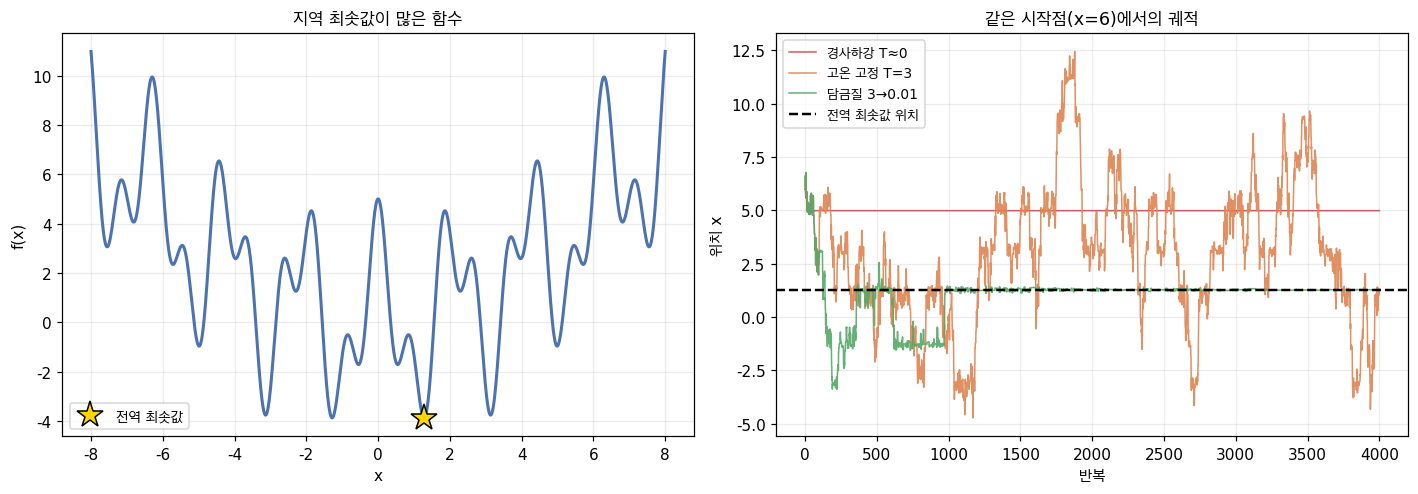

빨강(T≈0): 시작점 근처에서 바로 멈춥니다.
주황(고온): 끝까지 요동칩니다 — 어디에도 정착하지 못합니다.
초록(담금질): 처음엔 크게 움직이다가 점점 진폭이 줄며 정답 근처에 안착합니다.


In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

ax1.plot(xs_plot, f_multi(xs_plot), lw=2, color="#4c72b0")
ax1.plot(true_min_x, f_multi(true_min_x), "*", ms=18, color="gold",
         markeredgecolor="black", zorder=5, label="전역 최솟값")
ax1.set_xlabel("x"); ax1.set_ylabel("f(x)")
ax1.set_title("지역 최솟값이 많은 함수", fontsize=11.5)
ax1.legend(fontsize=9.5); ax1.grid(alpha=0.25)

# 궤적 비교
def sa_traj(T0, T_end, x0, n=4000, seed=0):
    rng = np.random.default_rng(seed)
    x, fx = x0, f_multi(x0)
    traj = [x]
    for k in range(n):
        T = T0 * (T_end/T0) ** (k/n)
        cand = x + rng.normal(0, 0.5)
        fc = f_multi(cand)
        if fc < fx or rng.random() < math.exp(-(fc-fx)/max(T, 1e-12)):
            x, fx = cand, fc
        traj.append(x)
    return np.array(traj)

for (name, T0, Te), color in [(("경사하강 T≈0", 1e-12, 1e-12), "#c44e52"),
                              (("고온 고정 T=3", 3.0, 3.0), "#dd8452"),
                              (("담금질 3→0.01", 3.0, 0.01), "#55a868")]:
    tr = sa_traj(T0, Te, 6.0, seed=11)
    ax2.plot(tr, lw=1.0, color=color, alpha=0.9, label=name)
ax2.axhline(true_min_x, color="black", ls="--", lw=1.6, label="전역 최솟값 위치")
ax2.set_xlabel("반복"); ax2.set_ylabel("위치 x")
ax2.set_title("같은 시작점(x=6)에서의 궤적", fontsize=11.5)
ax2.legend(fontsize=9); ax2.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("빨강(T≈0): 시작점 근처에서 바로 멈춥니다.")
print("주황(고온): 끝까지 요동칩니다 — 어디에도 정착하지 못합니다.")
print("초록(담금질): 처음엔 크게 움직이다가 점점 진폭이 줄며 정답 근처에 안착합니다.")

## 1️⃣2️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 사람들이 말하는 것 | 실제 의미 |
| --- | --- | --- |
| **랜덤 워크** | "동전 던지기 이동" | 매 걸음 무작위 증분으로 위치가 변하는 과정. **변위가 √n으로 커집니다** |
| **마르코프 성질** | "기억이 없다" | 미래가 현재 상태에만 의존. 과거 경로는 무관 |
| **전이 행렬** | "확률 표" | `P[i][j]` = `i`에서 `j`로 갈 확률. **각 행의 합이 1** |
| **정상 분포** | "장기 평균" | `πP = π`를 만족하는 분포. 연쇄의 평형 상태 |
| **스펙트럴 갭** | "얼마나 빨리 섞이나" | `1 − |λ₂|`. **혼합 시간 ≈ 1/갭** |
| **흡수 상태** | "들어가면 못 나옴" | `P[i][i] = 1`인 상태. EOS 토큰, 게임 종료 |
| **브라운 운동** | "무작위 진동" | 랜덤 워크의 연속 극한. `B(t) ~ N(0, t)`. **연속이지만 미분 불가능** |
| **랑주뱅 동역학** | "노이즈를 더한 경사하강" | 기울기 힘 + `√(2T·dt)` 노이즈. 볼츠만 분포로 수렴 |
| **모의 담금질** | "온도를 낮춰가며 탐색" | 고온에서 넓게 탐색하고 저온에서 정밀하게 수렴 |
| **디퓨전 과정** | "노이즈 넣고 빼기" | 순방향: 노이즈 추가(알려짐). 역방향: 노이즈 제거(학습됨) |
| **마팅게일** | "공정한 게임" | 미래의 기대값 = 현재 값. 도박꾼의 파산 공식의 근거 |

---

## 🎯 한 문장 정리

> **확률 과정은 "무작위성 + 시간에 따른 구조"입니다.
> 그리고 현대 AI의 생성 메커니즘 대부분이 이 틀 안에 있습니다.**

| 배운 것 | AI에서 |
| --- | --- |
| 랜덤 워크의 √n (1절) | SGD 노이즈 `1/√B`, 어텐션의 `1/√d_k` |
| 브라운 운동 (3절) | 디퓨전 모델의 순방향 노이즈 |
| 전이 행렬·정상 분포 (4~5절) | **PageRank**, MCMC 수렴 목표 |
| 스펙트럴 갭 (6절) | MCMC 혼합 속도 진단 |
| 흡수 상태 (7절) | EOS 토큰, RL 종료 상태 |
| 랑주뱅 동역학 (8절) | 스코어 기반 생성 모델, SGLD |
| **디퓨전 (9절)** | **Stable Diffusion, DDPM** |
| 온도 (10절) | LLM 샘플링, 담금질, RL 탐색 |

**LLM의 온도를 조절할 때 여러분은 마르코프 연쇄를 조정하고 있는 것이고,
디퓨전 모델을 학습할 때는 브라운 운동을 되돌리는 법을 배우는 것이며,
베이즈 추론을 돌릴 때는 사후분포로 수렴하는 연쇄를 만드는 것입니다.**

---

## 🏁 Phase 1 완주

이번 노트북이 **Phase 1(수학 기초)의 마지막 22단원**입니다.
선형대수 → 미적분 → 확률 → 정보이론 → 최적화 → 신호처리 → 그래프 → 확률과정까지 왔습니다.

---

## 📖 더 읽을거리

- **Ho, Jain, Abbeel (2020)** — [DDPM](https://arxiv.org/abs/2006.11239). 디퓨전 혁명을 연 논문. 순방향·역방향 연쇄의 명료한 유도
- **Song & Ermon (2019)** — [Generative Modeling by Estimating Gradients](https://arxiv.org/abs/1907.05600). 랑주뱅 동역학 기반 스코어 매칭
- **Roberts & Rosenthal (2004)** — General state space Markov chains and MCMC algorithms. MCMC가 언제 왜 작동하는가
- **Norris (1997)** — Markov Chains. 표준 교재. 수렴·정상분포·도달시간
- **Welling & Teh (2011)** — [Bayesian Learning via SGLD](https://www.stats.ox.ac.uk/~teh/research/compstats/WelTeh2011a.pdf). SGD와 랑주뱅의 결합